In [1]:
using LinearAlgebra
using Printf
using Statistics

# ==========================================
# 1. 共通の演算子構築用関数 (変更なし)
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]

    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    
    return Cdag
end

# ==========================================
# 2. ED と HF のソルバー (Hamiltonianを返すように一部修正)
# ==========================================
function solve_ed_state_vector(t_L::Float64, t_S::Float64, U::Float64, mu::Float64)
    Cdag = get_creation_ops()
    C_op = Dict{String, Matrix{Float64}}(); N_op = Dict{String, Matrix{Float64}}()
    for (key, op) in Cdag
        C_op[key] = op'
        N_op[key] = op * C_op[key]
    end

    hamil = zeros(Float64, 256, 256)
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end

    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end

    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end
    for op in values(N_op); hamil .+= -mu .* op; end

    F = eigen(Symmetric(hamil))
    # 測定用に hamil も返すように変更
    return F.vectors[:, 1], F.values[1], hamil
end

function solve_hf_state_vector(t_L::Float64, t_S::Float64, U::Float64, mu::Float64; max_iter=1000, tol=1e-8)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    
    n_up = [0.8, 0.2, 0.8, 0.2]; n_dn = [0.2, 0.8, 0.2, 0.8]
    eigvec_up = zeros(Float64, N_sites, N_sites); eigvec_dn = zeros(Float64, N_sites, N_sites)
    
    for iteration in 1:max_iter
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        
        F_up = eigen(Symmetric(H_up)); F_dn = eigen(Symmetric(H_dn))
        eigvec_up = F_up.vectors; eigvec_dn = F_dn.vectors
        
        new_n_up = eigvec_up[:, 1].^2 .+ eigvec_up[:, 2].^2
        new_n_dn = eigvec_dn[:, 1].^2 .+ eigvec_dn[:, 2].^2
            
        diff = maximum(abs.(new_n_up .- n_up)) + maximum(abs.(new_n_dn .- n_dn))
        if diff < tol; break; end
        
        alpha = 0.5
        n_up = alpha .* new_n_up .+ (1.0 - alpha) .* n_up
        n_dn = alpha .* new_n_dn .+ (1.0 - alpha) .* n_dn
    end

    Cdag = get_creation_ops()
    Ddag_up_1 = sum(eigvec_up[i, 1] * Cdag["$(i)u"] for i in 1:4)
    Ddag_up_2 = sum(eigvec_up[i, 2] * Cdag["$(i)u"] for i in 1:4)
    Ddag_dn_1 = sum(eigvec_dn[i, 1] * Cdag["$(i)d"] for i in 1:4)
    Ddag_dn_2 = sum(eigvec_dn[i, 2] * Cdag["$(i)d"] for i in 1:4)
    
    vac = zeros(Float64, 256); vac[1] = 1.0 
    hf_state = Ddag_up_1 * (Ddag_up_2 * (Ddag_dn_1 * (Ddag_dn_2 * vac)))
    hf_state = hf_state / norm(hf_state)

    return hf_state
end

# ==========================================
# 3. CRM Shadow (Common Randomized Measurements)
# ==========================================
# 8量子ビット分のランダムなパウリ測定基底(I, H, HS)を生成
function generate_random_unitaries()
    I2 = ComplexF64[1.0 0.0; 0.0 1.0]
    H  = ComplexF64[1.0 1.0; 1.0 -1.0] / sqrt(2)
    HS = ComplexF64[1.0 -im; 1.0 im] / sqrt(2)
    unitaries = [I2, H, HS]
    return [rand(unitaries) for _ in 1:8]
end

# 状態ベクトルと測定基底からシャドウスナップショット行列を作成
function sample_shadow(state_vec::Vector{Float64}, u_list)
    # 全系のユニタリ行列 U = u_8 ⊗ u_7 ⊗ ... ⊗ u_1 を構築
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        U_global = kron(u_list[i], U_global)
    end
    
    # 測定基底へ状態を回転し、確率分布を計算
    rotated_state = U_global * state_vec
    probs = abs2.(rotated_state)
    
    # 確率分布に基づく測定サンプリング (0〜255)
    r = rand()
    cum_prob = 0.0
    sampled_idx = 0
    for i in 1:256
        cum_prob += probs[i]
        if r <= cum_prob
            sampled_idx = i - 1
            break
        end
    end
    
    # 測定結果をビット配列に変換 (MSB -> LSB)
    b_bits = reverse(digits(sampled_idx, base=2, pad=8))
    
    # スナップショット行列 M^{-1}(U^dag |b><b| U) の構築
    I2 = ComplexF64[1.0 0.0; 0.0 1.0]
    rho_snap = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u = u_list[i]
        b = b_bits[i]
        state_b = (b == 0) ? ComplexF64[1.0, 0.0] : ComplexF64[0.0, 1.0]
        proj = u' * (state_b * state_b') * u
        local_rho = 3.0 .* proj - I2 # 単一量子ビットの逆チャネル
        rho_snap = kron(local_rho, rho_snap)
    end
    
    return rho_snap
end

# ==========================================
# 4. 実行と比較
# ==========================================
function main()
    t_L = 1.0
    t_S = 1.0
    U_val = 4.0 # 電子相関が強く、分散が出やすい条件
    mu = U_val / 2.0
    
    println("--- System Setup ---")
    println("U = $U_val, 4-site Hubbard Model")
    
    vec_ed, E_ED, hamil = solve_ed_state_vector(t_L, t_S, U_val, mu)
    vec_hf = solve_hf_state_vector(t_L, t_S, U_val, mu)
    
    # HFの事前厳密エネルギー
    E_exact_prior = real(dot(vec_hf, hamil * vec_hf))
    
    println("\n--- Running Classical Shadow & CRM Shadow ---")
    N_shots = 500
    println("Shots: $N_shots\n")
    
    e_std_list = Float64[]
    e_crm_list = Float64[]
    
    for shot in 1:N_shots
        # 1回のショットで「同じ」ランダム基底を ED と HF で共有する
        u_list = generate_random_unitaries()
        
        # [実験系] ED状態からのサンプリング (Standard Shadow)
        rho_snap_ed = sample_shadow(vec_ed, u_list)
        # 高速化のため Tr(Hρ) を dot(H, ρ) で計算 (Hは実対称行列)
        e_ed = real(dot(hamil, rho_snap_ed)) 
        
        # [事前状態] HF状態からのサンプリング
        rho_snap_hf = sample_shadow(vec_hf, u_list)
        e_hf = real(dot(hamil, rho_snap_hf))
        
        # 推定値の記録
        push!(e_std_list, e_ed)
        # CRM 推定量: (実験の揺らぎ) - (シミュレーションの揺らぎ) + (正確な事前知識)
        push!(e_crm_list, e_ed - e_hf + E_exact_prior)
    end
    
    # 統計処理
    mean_std = mean(e_std_list)
    err_std = std(e_std_list) / sqrt(N_shots)
    
    mean_crm = mean(e_crm_list)
    err_crm = std(e_crm_list) / sqrt(N_shots)
    
    @printf(" True Energy (ED)     : %10.6f\n", E_ED)
    @printf(" Std Shadow Estimate  : %10.6f ± %.6f\n", mean_std, err_std)
    @printf(" CRM Shadow Estimate  : %10.6f ± %.6f\n", mean_crm, err_crm)
    println("---------------------------------------------")
    @printf(" => Variance Reduction (Std / CRM) : %.1f x\n", (err_std / err_crm)^2)
end

main()


--- System Setup ---
U = 4.0, 4-site Hubbard Model

--- Running Classical Shadow & CRM Shadow ---
Shots: 500

 True Energy (ED)     : -10.102748
 Std Shadow Estimate  :  -9.310000 ± 0.447359
 CRM Shadow Estimate  : -10.411298 ± 0.551660
---------------------------------------------
 => Variance Reduction (Std / CRM) : 0.7 x


In [6]:
using Pkg
Pkg.add("Plots")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `~/RandomMeas.jl/Project.toml`
    Manifest No packages added to or removed from `~/RandomMeas.jl/Manifest.toml`


In [7]:
# 初回実行時は pkg> add Plots を実行してパッケージをインストールしてください
using LinearAlgebra
using Printf
using Statistics
using Plots

# ==========================================
# 1. 共通の演算子構築用関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]

    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    
    return Cdag
end

# ==========================================
# 2. ED と HF のソルバー
# ==========================================
function solve_ed_state_vector(t_L::Float64, t_S::Float64, U::Float64, mu::Float64)
    Cdag = get_creation_ops()
    C_op = Dict{String, Matrix{Float64}}(); N_op = Dict{String, Matrix{Float64}}()
    for (key, op) in Cdag
        C_op[key] = op'
        N_op[key] = op * C_op[key]
    end

    hamil = zeros(Float64, 256, 256)
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end

    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end

    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end
    for op in values(N_op); hamil .+= -mu .* op; end

    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1]
end

function solve_hf_state_vector(t_L::Float64, t_S::Float64, U::Float64, mu::Float64; max_iter=1000, tol=1e-8)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    
    n_up = [0.8, 0.2, 0.8, 0.2]; n_dn = [0.2, 0.8, 0.2, 0.8]
    eigvec_up = zeros(Float64, N_sites, N_sites); eigvec_dn = zeros(Float64, N_sites, N_sites)
    
    for iteration in 1:max_iter
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        
        F_up = eigen(Symmetric(H_up)); F_dn = eigen(Symmetric(H_dn))
        eigvec_up = F_up.vectors; eigvec_dn = F_dn.vectors
        
        new_n_up = eigvec_up[:, 1].^2 .+ eigvec_up[:, 2].^2
        new_n_dn = eigvec_dn[:, 1].^2 .+ eigvec_dn[:, 2].^2
            
        diff = maximum(abs.(new_n_up .- n_up)) + maximum(abs.(new_n_dn .- n_dn))
        if diff < tol; break; end
        
        alpha = 0.5
        n_up = alpha .* new_n_up .+ (1.0 - alpha) .* n_up
        n_dn = alpha .* new_n_dn .+ (1.0 - alpha) .* n_dn
    end

    Cdag = get_creation_ops()
    Ddag_up_1 = sum(eigvec_up[i, 1] * Cdag["$(i)u"] for i in 1:4)
    Ddag_up_2 = sum(eigvec_up[i, 2] * Cdag["$(i)u"] for i in 1:4)
    Ddag_dn_1 = sum(eigvec_dn[i, 1] * Cdag["$(i)d"] for i in 1:4)
    Ddag_dn_2 = sum(eigvec_dn[i, 2] * Cdag["$(i)d"] for i in 1:4)
    
    vac = zeros(Float64, 256); vac[1] = 1.0 
    hf_state = Ddag_up_1 * (Ddag_up_2 * (Ddag_dn_1 * (Ddag_dn_2 * vac)))
    hf_state = hf_state / norm(hf_state)

    return hf_state
end

# ==========================================
# 3. シャドウサンプリング
# ==========================================
function generate_random_unitaries()
    I2 = ComplexF64[1.0 0.0; 0.0 1.0]
    H  = ComplexF64[1.0 1.0; 1.0 -1.0] / sqrt(2)
    HS = ComplexF64[1.0 -im; 1.0 im] / sqrt(2)
    unitaries = [I2, H, HS]
    return [rand(unitaries) for _ in 1:8]
end

function sample_shadow(state_vec::Vector{Float64}, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        U_global = kron(u_list[i], U_global)
    end
    
    rotated_state = U_global * state_vec
    probs = abs2.(rotated_state)
    
    r = rand()
    cum_prob = 0.0
    sampled_idx = 0
    for i in 1:256
        cum_prob += probs[i]
        if r <= cum_prob
            sampled_idx = i - 1
            break
        end
    end
    
    b_bits = reverse(digits(sampled_idx, base=2, pad=8))
    
    I2 = ComplexF64[1.0 0.0; 0.0 1.0]
    rho_snap = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u = u_list[i]
        b = b_bits[i]
        state_b = (b == 0) ? ComplexF64[1.0, 0.0] : ComplexF64[0.0, 1.0]
        proj = u' * (state_b * state_b') * u
        local_rho = 3.0 .* proj - I2
        rho_snap = kron(local_rho, rho_snap)
    end
    
    return rho_snap
end

# ==========================================
# 4. 実行とグラフ化
# ==========================================
function main()
    t_L = 1.0
    t_S = 1.0
    
    println("シミュレーションを開始します...")

    # ---------------------------------------------------------
    # 分析1: ショット数依存性 (U = 2.0 に固定)
    # ---------------------------------------------------------
    U_fixed = 2.0
    mu_fixed = U_fixed / 2.0
    vec_ed_fixed = solve_ed_state_vector(t_L, t_S, U_fixed, mu_fixed)
    vec_hf_fixed = solve_hf_state_vector(t_L, t_S, U_fixed, mu_fixed)
    
    N_shots_max = 500
    f_std_samples = Float64[]
    f_crm_samples = Float64[]
    
    print("  ショット数依存性の計算中 (U=2.0)... ")
    for shot in 1:N_shots_max
        u_list = generate_random_unitaries()
        rho_ed = sample_shadow(vec_ed_fixed, u_list)
        rho_hf = sample_shadow(vec_hf_fixed, u_list)
        
        # O = |HF><HF| なので、Tr(ρ O) = <HF|ρ|HF> を計算
        val_ed = real(vec_hf_fixed' * rho_ed * vec_hf_fixed)
        val_hf = real(vec_hf_fixed' * rho_hf * vec_hf_fixed)
        
        push!(f_std_samples, val_ed)
        push!(f_crm_samples, val_ed - val_hf + 1.0) # CRM推定量
    end
    println("完了")
    
    # 標準誤差 (Standard Error) を計算
    shots_range = 10:20:N_shots_max
    err_std_shots = [std(f_std_samples[1:s]) / sqrt(s) for s in shots_range]
    err_crm_shots = [std(f_crm_samples[1:s]) / sqrt(s) for s in shots_range]
    
    p1 = plot(shots_range, err_std_shots, label="Standard Shadow", 
              lw=2, color=:blue, xlabel="Number of Shots", ylabel="Standard Error of Fidelity",
              title="Error vs Shots (U=2.0)", yaxis=:log, legend=:topright)
    plot!(p1, shots_range, err_crm_shots, label="CRM Shadow", lw=2, color=:red)

    # ---------------------------------------------------------
    # 分析2: 相互作用 U 依存性 (ショット数 = 300 に固定)
    # ---------------------------------------------------------
    U_range = 0.0:0.5:6.0
    N_fixed_shots = 300
    err_std_U = Float64[]
    err_crm_U = Float64[]
    
    println("  相互作用 U 依存性の計算中 (Shots=300)... ")
    for U_val in U_range
        @printf("    U = %.1f ...\n", U_val)
        mu_val = U_val / 2.0
        v_ed = solve_ed_state_vector(t_L, t_S, U_val, mu_val)
        v_hf = solve_hf_state_vector(t_L, t_S, U_val, mu_val)
        
        f_std = Float64[]
        f_crm = Float64[]
        for _ in 1:N_fixed_shots
            u_list = generate_random_unitaries()
            rho_ed = sample_shadow(v_ed, u_list)
            rho_hf = sample_shadow(v_hf, u_list)
            
            val_ed = real(v_hf' * rho_ed * v_hf)
            val_hf = real(v_hf' * rho_hf * v_hf)
            
            push!(f_std, val_ed)
            push!(f_crm, val_ed - val_hf + 1.0)
        end
        push!(err_std_U, std(f_std) / sqrt(N_fixed_shots))
        push!(err_crm_U, std(f_crm) / sqrt(N_fixed_shots))
    end
    println("完了")
    
    p2 = plot(U_range, err_std_U, label="Standard Shadow", 
              lw=2, color=:blue, xlabel="Interaction Strength (U)", ylabel="Standard Error",
              title="Error vs U (300 shots)", yaxis=:log, legend=:bottomright)
    plot!(p2, U_range, err_crm_U, label="CRM Shadow", lw=2, color=:red)
    
    # ---------------------------------------------------------
    # グラフの保存と表示
    # ---------------------------------------------------------
    final_plot = plot(p1, p2, layout=(1,2), size=(900, 400), margin=5Plots.mm)
    savefig(final_plot, "crm_fidelity_comparison.png")
    println("\nグラフを 'crm_fidelity_comparison.png' として保存しました。")
end

main()


シミュレーションを開始します...
  ショット数依存性の計算中 (U=2.0)... 完了
  相互作用 U 依存性の計算中 (Shots=300)... 
    U = 0.0 ...
    U = 0.5 ...
    U = 1.0 ...
    U = 1.5 ...
    U = 2.0 ...
    U = 2.5 ...
    U = 3.0 ...
    U = 3.5 ...
    U = 4.0 ...
    U = 4.5 ...
    U = 5.0 ...
    U = 5.5 ...
    U = 6.0 ...
完了

グラフを 'crm_fidelity_comparison.png' として保存しました。


Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM
=== Starting CRM Shadow Simulation ===
Shots per U = 300

Processing U = 0.0 ... True Fid = 0.0154 | CRM Error = 0.2475
Processing U = 0.5 ... True Fid = 0.4982 | CRM Error = 0.1942
Processing U = 1.0 ... True Fid = 0.4934 | CRM Error = 0.3006
Processing U = 1.5 ... True Fid = 0.4864 | CRM Error = 0.2206
Processing U = 2.0 ... True Fid = 0.4773 | CRM Error = 0.1962
Processing U = 2.5 ... True Fid = 0.4664 | CRM Error = 0.1592
Processing U = 3.0 ... True Fid = 0.4543 | CRM Error = 0.2976
Processing U = 3.5 ... True Fid = 0.4416 | CRM Error = 0.1900
Processing U = 4.0 ... True Fid = 0.4292 | CRM Error = 0.2334
Processing U = 4.5 ... True Fid = 0.4178 | CRM Error = 0.1933
Processing U = 5.0 ... True Fid = 0.4076 | CRM Error = 0.2500
Processing U = 5.5 ... True Fid = 0.3986 | CRM Error = 0.1718
Processing U = 6.0 ... True Fid = 0.3909 | CRM Error = 0.2021

Plotting results...
-> Saved graph to: /Users/ta

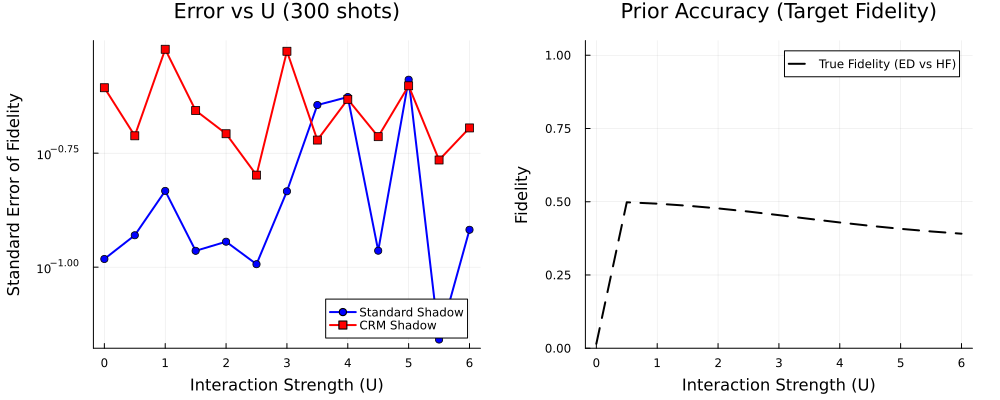

In [8]:
using LinearAlgebra
using Printf
using Statistics
using Plots

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. 共通の演算子構築用関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]

    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    
    return Cdag
end

function build_hamiltonian(t_L::Float64, t_S::Float64, U::Float64, mu::Float64)
    Cdag = get_creation_ops()
    C_op = Dict{String, Matrix{Float64}}()
    N_op = Dict{String, Matrix{Float64}}()
    for (key, op) in Cdag
        C_op[key] = op'
        N_op[key] = op * C_op[key]
    end

    hamil = zeros(Float64, 256, 256)
    
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end

    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end

    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end

    for op in values(N_op); hamil .+= -mu .* op; end
    
    return hamil
end

function solve_ed_state_vector(hamil::Matrix{Float64})
    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1], F.values[1]
end

function solve_hf_orbitals(t_L::Float64, t_S::Float64, U::Float64, mu::Float64; max_iter=1000, tol=1e-8)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    
    n_up = [0.8, 0.2, 0.8, 0.2]
    n_dn = [0.2, 0.8, 0.2, 0.8]
    
    eigvec_up = zeros(Float64, N_sites, N_sites)
    eigvec_dn = zeros(Float64, N_sites, N_sites)
    
    for iteration in 1:max_iter
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        
        F_up = eigen(Symmetric(H_up))
        F_dn = eigen(Symmetric(H_dn))
        
        eigvec_up = F_up.vectors
        eigvec_dn = F_dn.vectors
        
        new_n_up = eigvec_up[:, 1].^2 .+ eigvec_up[:, 2].^2
        new_n_dn = eigvec_dn[:, 1].^2 .+ eigvec_dn[:, 2].^2
            
        diff = maximum(abs.(new_n_up .- n_up)) + maximum(abs.(new_n_dn .- n_dn))
        if diff < tol; break; end
        
        alpha = 0.5
        n_up = alpha .* new_n_up .+ (1.0 - alpha) .* n_up
        n_dn = alpha .* new_n_dn .+ (1.0 - alpha) .* n_dn
    end
    
    return eigvec_up, eigvec_dn
end

function build_slater_determinant(up_idx, dn_idx, Ddag_up, Ddag_dn)
    vac = zeros(Float64, 256)
    vac[1] = 1.0
    res = vac
    for i in reverse(dn_idx); res = Ddag_dn[i] * res; end
    for i in reverse(up_idx); res = Ddag_up[i] * res; end
    return res / norm(res)
end

function get_hf_state_vector(eigvec_up::Matrix{Float64}, eigvec_dn::Matrix{Float64})
    Cdag = get_creation_ops()
    Ddag_up = [sum(eigvec_up[s, k] * Cdag["$(s)u"] for s in 1:4) for k in 1:4]
    Ddag_dn = [sum(eigvec_dn[s, k] * Cdag["$(s)d"] for s in 1:4) for k in 1:4]
    
    hf_state = build_slater_determinant([1, 2], [1, 2], Ddag_up, Ddag_dn)
    return hf_state
end

# ==========================================
# 2. シャドウサンプリング用関数
# ==========================================
function generate_random_unitaries()
    I2 = ComplexF64[1.0 0.0; 0.0 1.0]
    H  = ComplexF64[1.0 1.0; 1.0 -1.0] / sqrt(2)
    HS = ComplexF64[1.0 -im; 1.0 im] / sqrt(2)
    unitaries = [I2, H, HS]
    return [rand(unitaries) for _ in 1:8]
end

function sample_shadow(state_vec::Vector{Float64}, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        U_global = kron(u_list[i], U_global)
    end
    
    rotated_state = U_global * state_vec
    probs = abs2.(rotated_state)
    
    r = rand()
    cum_prob = 0.0
    sampled_idx = 0
    for i in 1:256
        cum_prob += probs[i]
        if r <= cum_prob
            sampled_idx = i - 1
            break
        end
    end
    
    b_bits = reverse(digits(sampled_idx, base=2, pad=8))
    
    I2 = ComplexF64[1.0 0.0; 0.0 1.0]
    rho_snap = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u = u_list[i]
        b = b_bits[i]
        state_b = (b == 0) ? ComplexF64[1.0, 0.0] : ComplexF64[0.0, 1.0]
        proj = u' * (state_b * state_b') * u
        local_rho = 3.0 .* proj - I2
        rho_snap = kron(local_rho, rho_snap)
    end
    
    return rho_snap
end

# ==========================================
# 3. メイン実行部 (U依存性の評価)
# ==========================================
function main()
    t_L = 1.0
    t_S = 1.0
    N_shots = 300 # 1つのUあたりの測定回数
    
    U_list = 0.0:0.5:6.0
    
    err_std_list = Float64[]
    err_crm_list = Float64[]
    true_fidelity_list = Float64[]
    
    println("=== Starting CRM Shadow Simulation ===")
    println("Shots per U = $N_shots\n")
    
    for U in U_list
        @printf("Processing U = %.1f ... ", U)
        mu = U / 2.0
        
        # 1. 状態の準備
        hamil = build_hamiltonian(t_L, t_S, U, mu)
        vec_ed, _ = solve_ed_state_vector(hamil) # [実験系] 真の量子状態
        
        eigvec_up, eigvec_dn = solve_hf_orbitals(t_L, t_S, U, mu)
        vec_hf = get_hf_state_vector(eigvec_up, eigvec_dn) # [事前知識] 近似状態
        
        # 真のFidelity
        true_fid = abs(dot(vec_ed, vec_hf))^2
        push!(true_fidelity_list, true_fid)
        
        f_std_samples = Float64[]
        f_crm_samples = Float64[]
        
        # 2. シャドウ測定のループ
        for shot in 1:N_shots
            # 両者で共通のランダム測定基底を使用
            u_list = generate_random_unitaries()
            
            rho_ed_snap = sample_shadow(vec_ed, u_list)
            rho_hf_snap = sample_shadow(vec_hf, u_list)
            
            # オブザーバブル O = |HF><HF| の期待値計算
            # Tr(rho * |HF><HF|) = <HF| rho |HF>
            val_ed = real(vec_hf' * rho_ed_snap * vec_hf)
            val_hf = real(vec_hf' * rho_hf_snap * vec_hf)
            
            push!(f_std_samples, val_ed)
            
            # CRM公式: 実験推定量 - シミュレーション推定量 + 正確な事前知識
            # 事前知識(HF状態)自身に対する |HF><HF| の期待値は必ず 1.0 になる
            push!(f_crm_samples, val_ed - val_hf + 1.0)
        end
        
        # 標準誤差 (Standard Error) の計算
        push!(err_std_list, std(f_std_samples) / sqrt(N_shots))
        push!(err_crm_list, std(f_crm_samples) / sqrt(N_shots))
        
        @printf("True Fid = %.4f | CRM Error = %.4f\n", true_fid, err_crm_list[end])
    end
    
    # ==========================================
    # 4. グラフ化と保存
    # ==========================================
    println("\nPlotting results...")
    
    # グラフ1: エラー（標準誤差）の比較
    p1 = plot(U_list, err_std_list, 
              label="Standard Shadow", 
              lw=2, marker=:circle, color=:blue,
              xlabel="Interaction Strength (U)", 
              ylabel="Standard Error of Fidelity",
              title="Error vs U ($N_shots shots)",
              yaxis=:log, legend=:bottomright,
              margin=5Plots.mm)
    plot!(p1, U_list, err_crm_list, 
          label="CRM Shadow", 
          lw=2, marker=:square, color=:red)

    # グラフ2: 真のFidelityの減衰
    p2 = plot(U_list, true_fidelity_list, 
              label="True Fidelity (ED vs HF)", 
              lw=2, color=:black, linestyle=:dash,
              xlabel="Interaction Strength (U)", 
              ylabel="Fidelity",
              title="Prior Accuracy (Target Fidelity)",
              legend=:topright, ylims=(0, 1.05),
              margin=5Plots.mm)

    final_plot = plot(p1, p2, layout=(1,2), size=(1000, 400))
    
    file_name = "crm_fidelity_U_sweep.png"
    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    
    println("-> Saved graph to: $save_full_path")
    display(final_plot)
end

main()

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM
=== Starting CRM Convergence Simulation ===
Processing U = 0.0 ... 
Processing U = 2.0 ... 
Processing U = 4.0 ... 
Processing U = 6.0 ... 

Plotting results...
-> Saved graph to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM/crm_fidelity_shots_convergence.png


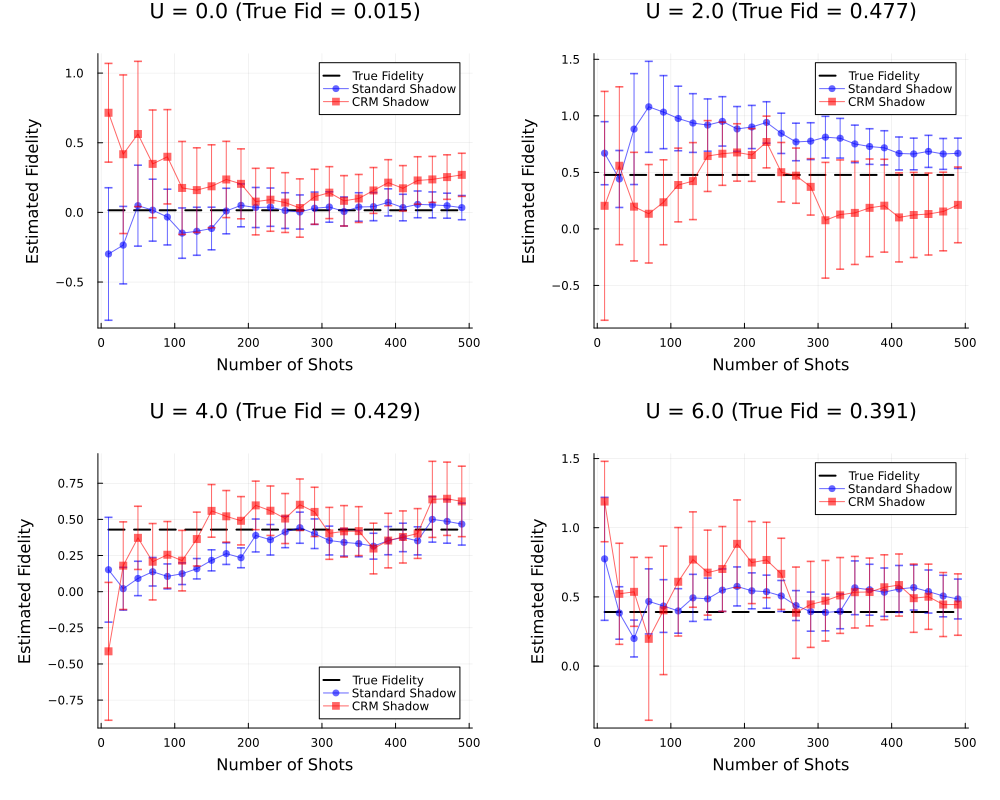

In [9]:
using LinearAlgebra
using Printf
using Statistics
using Plots

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. 共通の演算子構築用関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]

    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    
    return Cdag
end

function build_hamiltonian(t_L::Float64, t_S::Float64, U::Float64, mu::Float64)
    Cdag = get_creation_ops()
    C_op = Dict{String, Matrix{Float64}}()
    N_op = Dict{String, Matrix{Float64}}()
    for (key, op) in Cdag
        C_op[key] = op'
        N_op[key] = op * C_op[key]
    end

    hamil = zeros(Float64, 256, 256)
    
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end

    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end

    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end

    for op in values(N_op); hamil .+= -mu .* op; end
    
    return hamil
end

function solve_ed_state_vector(hamil::Matrix{Float64})
    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1], F.values[1]
end

function solve_hf_orbitals(t_L::Float64, t_S::Float64, U::Float64, mu::Float64; max_iter=1000, tol=1e-8)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    
    n_up = [0.8, 0.2, 0.8, 0.2]
    n_dn = [0.2, 0.8, 0.2, 0.8]
    
    eigvec_up = zeros(Float64, N_sites, N_sites)
    eigvec_dn = zeros(Float64, N_sites, N_sites)
    
    for iteration in 1:max_iter
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        
        F_up = eigen(Symmetric(H_up))
        F_dn = eigen(Symmetric(H_dn))
        
        eigvec_up = F_up.vectors
        eigvec_dn = F_dn.vectors
        
        new_n_up = eigvec_up[:, 1].^2 .+ eigvec_up[:, 2].^2
        new_n_dn = eigvec_dn[:, 1].^2 .+ eigvec_dn[:, 2].^2
            
        diff = maximum(abs.(new_n_up .- n_up)) + maximum(abs.(new_n_dn .- n_dn))
        if diff < tol; break; end
        
        alpha = 0.5
        n_up = alpha .* new_n_up .+ (1.0 - alpha) .* n_up
        n_dn = alpha .* new_n_dn .+ (1.0 - alpha) .* n_dn
    end
    
    return eigvec_up, eigvec_dn
end

function build_slater_determinant(up_idx, dn_idx, Ddag_up, Ddag_dn)
    vac = zeros(Float64, 256)
    vac[1] = 1.0
    res = vac
    for i in reverse(dn_idx); res = Ddag_dn[i] * res; end
    for i in reverse(up_idx); res = Ddag_up[i] * res; end
    return res / norm(res)
end

function get_hf_state_vector(eigvec_up::Matrix{Float64}, eigvec_dn::Matrix{Float64})
    Cdag = get_creation_ops()
    Ddag_up = [sum(eigvec_up[s, k] * Cdag["$(s)u"] for s in 1:4) for k in 1:4]
    Ddag_dn = [sum(eigvec_dn[s, k] * Cdag["$(s)d"] for s in 1:4) for k in 1:4]
    
    hf_state = build_slater_determinant([1, 2], [1, 2], Ddag_up, Ddag_dn)
    return hf_state
end

# ==========================================
# 2. シャドウサンプリング用関数
# ==========================================
function generate_random_unitaries()
    I2 = ComplexF64[1.0 0.0; 0.0 1.0]
    H  = ComplexF64[1.0 1.0; 1.0 -1.0] / sqrt(2)
    HS = ComplexF64[1.0 -im; 1.0 im] / sqrt(2)
    unitaries = [I2, H, HS]
    return [rand(unitaries) for _ in 1:8]
end

function sample_shadow(state_vec::Vector{Float64}, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        U_global = kron(u_list[i], U_global)
    end
    
    rotated_state = U_global * state_vec
    probs = abs2.(rotated_state)
    
    r = rand()
    cum_prob = 0.0
    sampled_idx = 0
    for i in 1:256
        cum_prob += probs[i]
        if r <= cum_prob
            sampled_idx = i - 1
            break
        end
    end
    
    b_bits = reverse(digits(sampled_idx, base=2, pad=8))
    
    I2 = ComplexF64[1.0 0.0; 0.0 1.0]
    rho_snap = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u = u_list[i]
        b = b_bits[i]
        state_b = (b == 0) ? ComplexF64[1.0, 0.0] : ComplexF64[0.0, 1.0]
        proj = u' * (state_b * state_b') * u
        local_rho = 3.0 .* proj - I2
        rho_snap = kron(local_rho, rho_snap)
    end
    
    return rho_snap
end

# ==========================================
# 3. メイン実行部 (各Uでの測定回数 vs 収束)
# ==========================================
function main()
    t_L = 1.0
    t_S = 1.0
    
    # 代表的なUの値をピックアップして比較
    U_list = [0.0, 2.0, 4.0, 6.0]
    N_shots_max = 500
    
    # グラフのプロットポイント（10回ごと〜最大500回まで計算）
    shots_range = 10:20:N_shots_max 
    
    println("=== Starting CRM Convergence Simulation ===")
    
    plots_array = [] # 各Uのグラフを格納する配列
    
    for U in U_list
        @printf("Processing U = %.1f ... \n", U)
        mu = U / 2.0
        
        hamil = build_hamiltonian(t_L, t_S, U, mu)
        vec_ed, _ = solve_ed_state_vector(hamil) 
        
        eigvec_up, eigvec_dn = solve_hf_orbitals(t_L, t_S, U, mu)
        vec_hf = get_hf_state_vector(eigvec_up, eigvec_dn)
        
        # 真のFidelity
        true_fid = abs(dot(vec_ed, vec_hf))^2
        
        f_std_samples = Float64[]
        f_crm_samples = Float64[]
        
        # N_shots_max 回分の生データを一気にサンプリング
        for shot in 1:N_shots_max
            u_list = generate_random_unitaries()
            rho_ed_snap = sample_shadow(vec_ed, u_list)
            rho_hf_snap = sample_shadow(vec_hf, u_list)
            
            val_ed = real(vec_hf' * rho_ed_snap * vec_hf)
            val_hf = real(vec_hf' * rho_hf_snap * vec_hf)
            
            push!(f_std_samples, val_ed)
            push!(f_crm_samples, val_ed - val_hf + 1.0)
        end
        
        # --- 測定回数(s)ごとの 平均値 と 標準誤差 を計算 ---
        mean_std_shots = [mean(f_std_samples[1:s]) for s in shots_range]
        err_std_shots  = [std(f_std_samples[1:s]) / sqrt(s) for s in shots_range]
        
        mean_crm_shots = [mean(f_crm_samples[1:s]) for s in shots_range]
        err_crm_shots  = [std(f_crm_samples[1:s]) / sqrt(s) for s in shots_range]
        
        # --- このUにおけるグラフを作成 ---
        # 1. 真の値のライン
        p = plot(shots_range, fill(true_fid, length(shots_range)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash)
                 
        # 2. Standard Shadow のプロット (エラーバー付き)
        plot!(p, shots_range, mean_std_shots, yerror=err_std_shots, 
              label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
              
        # 3. CRM Shadow のプロット (エラーバー付き)
        plot!(p, shots_range, mean_crm_shots, yerror=err_crm_shots, 
              label="CRM Shadow", marker=:square, color=:red, msc=:red, alpha=0.6)
        
        # グラフの装飾
        title!(p, "U = $U (True Fid = $(round(true_fid, digits=3)))")
        xlabel!(p, "Number of Shots")
        ylabel!(p, "Estimated Fidelity")
        
        push!(plots_array, p)
    end
    
    # ==========================================
    # 4. グラフ化と保存 (2x2レイアウト)
    # ==========================================
    println("\nPlotting results...")
    
    # 4つのグラフを 2x2 のレイアウトで一枚の画像に結合
    final_plot = plot(plots_array..., layout=(2, 2), size=(1000, 800), margin=6Plots.mm)
    
    file_name = "crm_fidelity_shots_convergence.png"
    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    
    println("-> Saved graph to: $save_full_path")
    display(final_plot)
end

main()

In [10]:
using LinearAlgebra
using Printf
using Statistics
using Plots

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. 共通の演算子構築用関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]

    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    
    return Cdag
end

function build_hamiltonian(t_L::Float64, t_S::Float64, U::Float64, mu::Float64)
    Cdag = get_creation_ops()
    C_op = Dict{String, Matrix{Float64}}()
    N_op = Dict{String, Matrix{Float64}}()
    for (key, op) in Cdag
        C_op[key] = op'
        N_op[key] = op * C_op[key]
    end

    hamil = zeros(Float64, 256, 256)
    
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end

    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end

    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end

    for op in values(N_op); hamil .+= -mu .* op; end
    
    return hamil
end

function solve_ed_state_vector(hamil::Matrix{Float64})
    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1], F.values[1]
end

function solve_hf_orbitals(t_L::Float64, t_S::Float64, U::Float64, mu::Float64; max_iter=1000, tol=1e-8)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    
    n_up = [0.8, 0.2, 0.8, 0.2]
    n_dn = [0.2, 0.8, 0.2, 0.8]
    
    eigvec_up = zeros(Float64, N_sites, N_sites)
    eigvec_dn = zeros(Float64, N_sites, N_sites)
    
    for iteration in 1:max_iter
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        
        F_up = eigen(Symmetric(H_up))
        F_dn = eigen(Symmetric(H_dn))
        
        eigvec_up = F_up.vectors
        eigvec_dn = F_dn.vectors
        
        new_n_up = eigvec_up[:, 1].^2 .+ eigvec_up[:, 2].^2
        new_n_dn = eigvec_dn[:, 1].^2 .+ eigvec_dn[:, 2].^2
            
        diff = maximum(abs.(new_n_up .- n_up)) + maximum(abs.(new_n_dn .- n_dn))
        if diff < tol; break; end
        
        alpha = 0.5
        n_up = alpha .* new_n_up .+ (1.0 - alpha) .* n_up
        n_dn = alpha .* new_n_dn .+ (1.0 - alpha) .* n_dn
    end
    
    return eigvec_up, eigvec_dn
end

function build_slater_determinant(up_idx, dn_idx, Ddag_up, Ddag_dn)
    vac = zeros(Float64, 256)
    vac[1] = 1.0
    res = vac
    for i in reverse(dn_idx); res = Ddag_dn[i] * res; end
    for i in reverse(up_idx); res = Ddag_up[i] * res; end
    return res / norm(res)
end

function get_hf_state_vector(eigvec_up::Matrix{Float64}, eigvec_dn::Matrix{Float64})
    Cdag = get_creation_ops()
    Ddag_up = [sum(eigvec_up[s, k] * Cdag["$(s)u"] for s in 1:4) for k in 1:4]
    Ddag_dn = [sum(eigvec_dn[s, k] * Cdag["$(s)d"] for s in 1:4) for k in 1:4]
    
    hf_state = build_slater_determinant([1, 2], [1, 2], Ddag_up, Ddag_dn)
    return hf_state
end

# ==========================================
# 2. シャドウサンプリング用関数（高速化のため分割）
# ==========================================
function generate_random_unitaries()
    I2 = ComplexF64[1.0 0.0; 0.0 1.0]
    H  = ComplexF64[1.0 1.0; 1.0 -1.0] / sqrt(2)
    HS = ComplexF64[1.0 -im; 1.0 im] / sqrt(2)
    unitaries = [I2, H, HS]
    return [rand(unitaries) for _ in 1:8]
end

# nm回のサンプリングで確率計算を使い回せるように関数を分離
function get_measurement_probs(state_vec::Vector{Float64}, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        U_global = kron(u_list[i], U_global)
    end
    rotated_state = U_global * state_vec
    return abs2.(rotated_state)
end

function sample_index(probs::Vector{Float64})
    r = rand()
    cum_prob = 0.0
    for i in 1:256
        cum_prob += probs[i]
        if r <= cum_prob
            return i - 1
        end
    end
    return 255
end

function build_snapshot(sampled_idx::Int, u_list)
    b_bits = reverse(digits(sampled_idx, base=2, pad=8))
    I2 = ComplexF64[1.0 0.0; 0.0 1.0]
    rho_snap = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u = u_list[i]
        b = b_bits[i]
        state_b = (b == 0) ? ComplexF64[1.0, 0.0] : ComplexF64[0.0, 1.0]
        proj = u' * (state_b * state_b') * u
        local_rho = 3.0 .* proj - I2
        rho_snap = kron(local_rho, rho_snap)
    end
    return rho_snap
end

# ==========================================
# 3. メイン実行部 (nu × nm と n_repeat の実装)
# ==========================================
function main()
    t_L = 1.0
    t_S = 1.0
    
    # 指示された測定セッティング
    settings_list = [
        (nu=10,   nm=10),
        (nu=20,   nm=50),
        (nu=50,   nm=100),
        (nu=100,  nm=200),
        (nu=200,  nm=500),
        (nu=500,  nm=1000)
    ]
    n_repeat = 15
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    U_list = [0.0, 2.0, 4.0, 6.0]
    
    plots_array = []
    
    println("=== Starting CRM Convergence Simulation ===")
    println("WARNING: Largest setting (nu=500, nm=1000) × 15 repeats per U is extremely heavy.")
    println("This may take a considerable amount of time. Sit back and relax!\n")
    
    for U in U_list
        @printf("Processing U = %.1f ... \n", U)
        mu = U / 2.0
        
        hamil = build_hamiltonian(t_L, t_S, U, mu)
        vec_ed, _ = solve_ed_state_vector(hamil) 
        
        eigvec_up, eigvec_dn = solve_hf_orbitals(t_L, t_S, U, mu)
        vec_hf = get_hf_state_vector(eigvec_up, eigvec_dn)
        
        true_fid = abs(dot(vec_ed, vec_hf))^2
        @printf("  True Fidelity: %.4f\n", true_fid)
        
        mean_std_list = Float64[]
        err_std_list  = Float64[]
        mean_crm_list = Float64[]
        err_crm_list  = Float64[]
        
        for (nu, nm) in settings_list
            @printf("  -> Simulating nu=%3d, nm=%4d (Total: %6d shots) ... ", nu, nm, nu * nm)
            
            temp_standard = Float64[]
            temp_crm = Float64[]
            
            for rep in 1:n_repeat
                val_std_nu = 0.0
                val_crm_nu = 0.0
                
                # nu 個のランダム基底についてループ
                for r in 1:nu
                    u_list = generate_random_unitaries()
                    
                    # 確率計算はユニタリごとに1回だけで済ませる（高速化）
                    probs_ed = get_measurement_probs(vec_ed, u_list)
                    probs_hf = get_measurement_probs(vec_hf, u_list)
                    
                    sum_ed = 0.0
                    sum_hf = 0.0
                    
                    # 各基底で nm 回のサンプリング
                    for m in 1:nm
                        idx_ed = sample_index(probs_ed)
                        rho_ed = build_snapshot(idx_ed, u_list)
                        sum_ed += real(vec_hf' * rho_ed * vec_hf)
                        
                        idx_hf = sample_index(probs_hf)
                        rho_hf = build_snapshot(idx_hf, u_list)
                        sum_hf += real(vec_hf' * rho_hf * vec_hf)
                    end
                    
                    val_std_nu += sum_ed / nm
                    val_crm_nu += (sum_ed - sum_hf) / nm
                end
                
                # nu 個の平均をとって1回の試行（rep）の推定量とする
                push!(temp_standard, val_std_nu / nu)
                push!(temp_crm, (val_crm_nu / nu) + 1.0)
            end
            
            # n_repeat 回の試行結果から平均とエラーバー（標準偏差）を計算
            push!(mean_std_list, mean(temp_standard))
            push!(err_std_list, std(temp_standard))
            push!(mean_crm_list, mean(temp_crm))
            push!(err_crm_list, std(temp_crm))
            
            println("Done.")
        end
        
        # --- グラフの作成 ---
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash,
                 xscale=:log10, margin=5Plots.mm)
                 
        plot!(p, total_shots_list, mean_std_list, yerror=err_std_list, 
              label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
              
        plot!(p, total_shots_list, mean_crm_list, yerror=err_crm_list, 
              label="CRM Shadow", marker=:square, color=:red, msc=:red, alpha=0.6)
        
        title!(p, "U = $U (True Fid = $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots (nu × nm)")
        ylabel!(p, "Estimated Fidelity")
        
        push!(plots_array, p)
        println("--------------------------------------------------")
    end
    
    # ==========================================
    # 4. グラフ化と保存
    # ==========================================
    println("\nPlotting combined results...")
    
    final_plot = plot(plots_array..., layout=(2, 2), size=(1100, 800), margin=6Plots.mm)
    
    file_name = "crm_fidelity_nu_nm_convergence.png"
    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    
    println("-> Saved graph to: $save_full_path")
    display(final_plot)
end

main()

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM
=== Starting CRM Convergence Simulation ===
This may take a considerable amount of time. Sit back and relax!

Processing U = 0.0 ... 
  True Fidelity: 0.0154
  -> Simulating nu= 10, nm=  10 (Total:    100 shots) ... Done.
  -> Simulating nu= 20, nm=  50 (Total:   1000 shots) ... Done.
  -> Simulating nu= 50, nm= 100 (Total:   5000 shots) ... Done.
  -> Simulating nu=100, nm= 200 (Total:  20000 shots) ... 

InterruptException: InterruptException:

In [3]:
using LinearAlgebra
using Printf
using Statistics
using Plots

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_Fast")
mkpath(desktop_path)
println("画像は次の場所に保存されます: $desktop_path")

# ==========================================
# 1. ハミルトニアンと状態の構築関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]
    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    return Cdag
end

function build_hamiltonian(t_L, t_S, U, mu)
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    hamil = zeros(Float64, 256, 256)
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end
    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end
    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end
    for op in values(N_op); hamil .+= -mu .* op; end
    return hamil
end

function solve_ed_state_vector(hamil)
    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1]
end

function solve_hf_orbitals(t_L, t_S, U, mu)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    n_up, n_dn = [0.8, 0.2, 0.8, 0.2], [0.2, 0.8, 0.2, 0.8]
    ev_up, ev_dn = zeros(4, 4), zeros(4, 4)
    for iteration in 1:200
        H_up, H_dn = T + diagm(U .* n_dn) - mu * I, T + diagm(U .* n_up) - mu * I
        F_up, F_dn = eigen(Symmetric(H_up)), eigen(Symmetric(H_dn))
        ev_up, ev_dn = F_up.vectors, F_dn.vectors
        new_n_up = ev_up[:, 1].^2 .+ ev_up[:, 2].^2
        new_n_dn = ev_dn[:, 1].^2 .+ ev_dn[:, 2].^2
        if maximum(abs.(new_n_up .- n_up)) < 1e-8; break; end
        n_up, n_dn = 0.5 .* new_n_up .+ 0.5 .* n_up, 0.5 .* new_n_dn .+ 0.5 .* n_dn
    end
    return ev_up, ev_dn
end

function get_hf_state_vector(ev_up, ev_dn)
    Cdag = get_creation_ops()
    D_up = [sum(ev_up[s, k] * Cdag["$(s)u"] for s in 1:4) for k in 1:4]
    D_dn = [sum(ev_dn[s, k] * Cdag["$(s)d"] for s in 1:4) for k in 1:4]
    vac = zeros(256); vac[1] = 1.0
    res = D_up[1] * D_up[2] * D_dn[1] * D_dn[2] * vac
    return res / norm(res)
end

# ==========================================
# 2. 高速化シャドウサンプリング
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 3. メイン (軽量設定)
# ==========================================
function main()
    t_L, t_S = 1.0, 1.0
    # ★軽量設定に変更
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 5
    U_list = [0.1, 4.0]
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    println("=== 高速版 CRM シミュレーションを開始します ===")
    
    for U in U_list
        @printf("U = %.1f を計算中...\n", U)
        mu = U / 2.0
        vec_ed = solve_ed_state_vector(build_hamiltonian(t_L, t_S, U, mu))
        ev_up, ev_dn = solve_hf_orbitals(t_L, t_S, U, mu)
        vec_hf = get_hf_state_vector(ev_up, ev_dn)
        true_fid = abs(dot(vec_ed, vec_hf))^2
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_ed, p_hf = get_measurement_probs(vec_ed, u_l), get_measurement_probs(vec_hf, u_l)
                    s_ed, s_hf = 0.0, 0.0
                    for m in 1:nm
                        s_ed += real(vec_hf' * build_snapshot(sample_index(p_ed), u_l) * vec_hf)
                        s_hf += real(vec_hf' * build_snapshot(sample_index(p_hf), u_l) * vec_hf)
                    end
                    v_std_nu += s_ed / nm
                    v_crm_nu += (s_ed - s_hf) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard", marker=:circle, color=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM", marker=:square, color=:red, alpha=0.6)
        title!(p, "U = $U (True Fid: $(round(true_fid, digits=2)))")
        push!(plots_array, p)
    end
    
    final_plot = plot(plots_array..., layout=(2, 2), size=(1000, 800), margin=5Plots.mm)
    savefig(final_plot, joinpath(desktop_path, "crm_fast_result.png"))
    println("完了しました。画像を確認してください。")
end

main()

画像は次の場所に保存されます: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_Fast
=== 高速版 CRM シミュレーションを開始します ===
U = 0.1 を計算中...
U = 4.0 を計算中...
完了しました。画像を確認してください。


In [ ]:
using LinearAlgebra
using Printf
using Statistics
using Plots

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_CISD")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. ハミルトニアンと演算子の構築関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]
    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    return Cdag
end

function build_hamiltonian(t_L, t_S, U, mu)
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    hamil = zeros(Float64, 256, 256)
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end
    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end
    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end
    for op in values(N_op); hamil .+= -mu .* op; end
    return hamil
end

function solve_ed_state_vector(hamil::Matrix{Float64})
    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1]
end

# ==========================================
# 2. 近似手法 (HF -> CISD)
# ==========================================
function solve_hf_orbitals(t_L, t_S, U, mu)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    n_up, n_dn = [0.8, 0.2, 0.8, 0.2], [0.2, 0.8, 0.2, 0.8]
    ev_up, ev_dn = zeros(4, 4), zeros(4, 4)
    for iteration in 1:200
        H_up, H_dn = T + diagm(U .* n_dn) - mu * I, T + diagm(U .* n_up) - mu * I
        F_up, F_dn = eigen(Symmetric(H_up)), eigen(Symmetric(H_dn))
        ev_up, ev_dn = F_up.vectors, F_dn.vectors
        new_n_up = ev_up[:, 1].^2 .+ ev_up[:, 2].^2
        new_n_dn = ev_dn[:, 1].^2 .+ ev_dn[:, 2].^2
        if maximum(abs.(new_n_up .- n_up)) < 1e-8; break; end
        n_up, n_dn = 0.5 .* new_n_up .+ 0.5 .* n_up, 0.5 .* new_n_dn .+ 0.5 .* n_dn
    end
    return ev_up, ev_dn
end

function build_slater_determinant(up_idx, dn_idx, D_up, D_dn)
    vac = zeros(256); vac[1] = 1.0
    res = vac
    for i in reverse(dn_idx); res = D_dn[i] * res; end
    for i in reverse(up_idx); res = D_up[i] * res; end
    return res / norm(res)
end

function solve_cisd_state_vector(hamil::Matrix{Float64}, ev_up::Matrix{Float64}, ev_dn::Matrix{Float64})
    Cdag = get_creation_ops()
    D_up = [sum(ev_up[s, k] * Cdag["$(s)u"] for s in 1:4) for k in 1:4]
    D_dn = [sum(ev_dn[s, k] * Cdag["$(s)d"] for s in 1:4) for k in 1:4]
    
    # 励起パターンの定義 (占有軌道:1,2 / 仮想軌道:3,4)
    unex = [[1, 2]]
    singles = [[2, 3], [2, 4], [1, 3], [1, 4]]
    doubles = [[3, 4]]
    
    basis = Vector{Vector{Float64}}()
    
    # 0-ex (HF State)
    push!(basis, build_slater_determinant(unex[1], unex[1], D_up, D_dn))
    
    # 1-ex (Singles)
    for u in singles; push!(basis, build_slater_determinant(u, unex[1], D_up, D_dn)); end
    for d in singles; push!(basis, build_slater_determinant(unex[1], d, D_up, D_dn)); end
    
    # 2-ex (Doubles)
    push!(basis, build_slater_determinant(doubles[1], unex[1], D_up, D_dn))
    push!(basis, build_slater_determinant(unex[1], doubles[1], D_up, D_dn))
    for u in singles
        for d in singles
            push!(basis, build_slater_determinant(u, d, D_up, D_dn))
        end
    end
    
    # CISDハミルトニアンの構築と対角化 (27次元)
    V = hcat(basis...)
    H_CISD = V' * hamil * V
    F = eigen(Symmetric(H_CISD))
    
    return V * F.vectors[:, 1]
end

# ==========================================
# 3. 高速化シャドウサンプリング
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 4. メイン実行部
# ==========================================
function main()
    t_L, t_S = 1.0, 1.0
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 5
    U_list = [0.1, 4.0]
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    println("=== Starting CRM Simulation with CISD Prior ===")
    
    for U in U_list
        @printf("Processing U = %.1f ...\n", U)
        mu = U / 2.0
        
        # モデルの構築
        hamil = build_hamiltonian(t_L, t_S, U, mu)
        vec_ed = solve_ed_state_vector(hamil)
        
        # CISD事前状態の構築
        ev_up, ev_dn = solve_hf_orbitals(t_L, t_S, U, mu)
        vec_cisd = solve_cisd_state_vector(hamil, ev_up, ev_dn)
        
        true_fid = abs(dot(vec_ed, vec_cisd))^2
        @printf("  -> CISD True Fidelity: %.4f\n", true_fid)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_ed = get_measurement_probs(vec_ed, u_l)
                    p_cisd = get_measurement_probs(vec_cisd, u_l)
                    
                    s_ed, s_cisd = 0.0, 0.0
                    for m in 1:nm
                        # オブザーバブルは O = |CISD><CISD|
                        s_ed += real(vec_cisd' * build_snapshot(sample_index(p_ed), u_l) * vec_cisd)
                        s_cisd += real(vec_cisd' * build_snapshot(sample_index(p_cisd), u_l) * vec_cisd)
                    end
                    v_std_nu += s_ed / nm
                    v_crm_nu += (s_ed - s_cisd) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        # グラフの作成 (英語ラベル)
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (CISD Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (CISD Fid: $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    final_plot = plot(plots_array..., layout=(2, 2), size=(1000, 800), margin=5Plots.mm)
    savefig(final_plot, joinpath(desktop_path, "crm_cisd_fast_result.png"))
    println("\nSimulation complete! Graph saved to desktop.")
end

main()

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_CISD
=== Starting CRM Simulation with CISD Prior ===
Processing U = 0.1 ...
  -> CISD True Fidelity: 0.7121
Processing U = 4.0 ...
  -> CISD True Fidelity: 0.6723

Simulation complete! Graph saved to desktop.


# 画像を別名で保存

In [ ]:

# ... (前述の演算子構築、ハミルトニアン、HF/CISDソルバー、シャドウサンプリング関数は変更なし)
using LinearAlgebra
using Printf
using Statistics
using Plots

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_CISD")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. ハミルトニアンと演算子の構築関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]
    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    return Cdag
end

function build_hamiltonian(t_L, t_S, U, mu)
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    hamil = zeros(Float64, 256, 256)
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end
    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end
    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end
    for op in values(N_op); hamil .+= -mu .* op; end
    return hamil
end

function solve_ed_state_vector(hamil::Matrix{Float64})
    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1]
end

# ==========================================
# 2. 近似手法 (HF -> CISD)
# ==========================================
function solve_hf_orbitals(t_L, t_S, U, mu)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    n_up, n_dn = [0.8, 0.2, 0.8, 0.2], [0.2, 0.8, 0.2, 0.8]
    ev_up, ev_dn = zeros(4, 4), zeros(4, 4)
    for iteration in 1:200
        H_up, H_dn = T + diagm(U .* n_dn) - mu * I, T + diagm(U .* n_up) - mu * I
        F_up, F_dn = eigen(Symmetric(H_up)), eigen(Symmetric(H_dn))
        ev_up, ev_dn = F_up.vectors, F_dn.vectors
        new_n_up = ev_up[:, 1].^2 .+ ev_up[:, 2].^2
        new_n_dn = ev_dn[:, 1].^2 .+ ev_dn[:, 2].^2
        if maximum(abs.(new_n_up .- n_up)) < 1e-8; break; end
        n_up, n_dn = 0.5 .* new_n_up .+ 0.5 .* n_up, 0.5 .* new_n_dn .+ 0.5 .* n_dn
    end
    return ev_up, ev_dn
end

function build_slater_determinant(up_idx, dn_idx, D_up, D_dn)
    vac = zeros(256); vac[1] = 1.0
    res = vac
    for i in reverse(dn_idx); res = D_dn[i] * res; end
    for i in reverse(up_idx); res = D_up[i] * res; end
    return res / norm(res)
end

function solve_cisd_state_vector(hamil::Matrix{Float64}, ev_up::Matrix{Float64}, ev_dn::Matrix{Float64})
    Cdag = get_creation_ops()
    D_up = [sum(ev_up[s, k] * Cdag["$(s)u"] for s in 1:4) for k in 1:4]
    D_dn = [sum(ev_dn[s, k] * Cdag["$(s)d"] for s in 1:4) for k in 1:4]
    
    # 励起パターンの定義 (占有軌道:1,2 / 仮想軌道:3,4)
    unex = [[1, 2]]
    singles = [[2, 3], [2, 4], [1, 3], [1, 4]]
    doubles = [[3, 4]]
    
    basis = Vector{Vector{Float64}}()
    
    # 0-ex (HF State)
    push!(basis, build_slater_determinant(unex[1], unex[1], D_up, D_dn))
    
    # 1-ex (Singles)
    for u in singles; push!(basis, build_slater_determinant(u, unex[1], D_up, D_dn)); end
    for d in singles; push!(basis, build_slater_determinant(unex[1], d, D_up, D_dn)); end
    
    # 2-ex (Doubles)
    push!(basis, build_slater_determinant(doubles[1], unex[1], D_up, D_dn))
    push!(basis, build_slater_determinant(unex[1], doubles[1], D_up, D_dn))
    for u in singles
        for d in singles
            push!(basis, build_slater_determinant(u, d, D_up, D_dn))
        end
    end
    
    # CISDハミルトニアンの構築と対角化 (27次元)
    V = hcat(basis...)
    H_CISD = V' * hamil * V
    F = eigen(Symmetric(H_CISD))
    
    return V * F.vectors[:, 1]
end

# ==========================================
# 3. 高速化シャドウサンプリング
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end


using Dates # ★日時取得のための標準ライブラリを追加

# ==========================================
# 4. メイン実行部 (ここを変更)
# ==========================================
function main()
    t_L, t_S = 1.0, 1.0
    # 軽量設定
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 20
    U_list = [0.1, 4.0]
    
    # 保存先の準備 (以前と同じ)
    desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_CISD")
    mkpath(desktop_path)
    println("Images will be saved to: $desktop_path")

    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    println("=== Starting CRM Simulation with CISD Prior ===")
    
    for U in U_list
        @printf("Processing U = %.1f ...\n", U)
        mu = U / 2.0
        # mu = 0 # ★化学ポテンシャルを0に固定して、CISDの真の忠実度を高くする
        
        # モデルの構築
        hamil = build_hamiltonian(t_L, t_S, U, mu)
        vec_ed = solve_ed_state_vector(hamil)
        
        # CISD事前状態の構築
        ev_up, ev_dn = solve_hf_orbitals(t_L, t_S, U, mu)
        vec_cisd = solve_cisd_state_vector(hamil, ev_up, ev_dn)
        
        true_fid = abs(dot(vec_ed, vec_cisd))^2
        @printf("  -> CISD True Fidelity: %.4f\n", true_fid)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_ed = get_measurement_probs(vec_ed, u_l)
                    p_cisd = get_measurement_probs(vec_cisd, u_l)
                    
                    s_ed, s_cisd = 0.0, 0.0
                    for m in 1:nm
                        # オブザーバブルは O = |CISD><CISD|
                        s_ed += real(vec_cisd' * build_snapshot(sample_index(p_ed), u_l) * vec_cisd)
                        s_cisd += real(vec_cisd' * build_snapshot(sample_index(p_cisd), u_l) * vec_cisd)
                    end
                    v_std_nu += s_ed / nm
                    v_crm_nu += (s_ed - s_cisd) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        # グラフの作成 (英語ラベル、エラーバーの色を修正)
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        # msc=:blue, msc=:red を追加してエラーバーの色を修正
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (CISD Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (CISD Fid: $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    final_plot = plot(plots_array..., layout=(2, 2), size=(1000, 800), margin=5Plots.mm)

    # ==========================================
    # 4. グラフの保存 (ここを変更)
    # ==========================================
    println("\nプロットを生成中...")

    # --- 新たな名前で保存するための処理を追加 ---
    # 現在の日時を取得し、ファイル名に使用できる形式の文字列にする (例: 2024-05-20_153045)
    current_time = now()
    timestamp_str = Dates.format(current_time, "yyyy-mm-dd_HHMMSS")

    # ファイル名にタイムスタンプを挿入する
    file_name = "crm_cisd_fast_result_$(timestamp_str).png"
    # file_name = "crm_cisd_fast_mu=0_result_$(timestamp_str).png"

    # ----------------------------------------

    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    println("完了しました。画像を確認してください: $file_name")
end

main()

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_CISD
Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_CISD
=== Starting CRM Simulation with CISD Prior ===
Processing U = 0.1 ...
  -> CISD True Fidelity: 0.0000
Processing U = 4.0 ...
  -> CISD True Fidelity: 0.0000

プロットを生成中...
完了しました。画像を確認してください: crm_cisd_fast_mu=0_result_2026-04-22_112941.png


# mu変化させておk

In [13]:
using LinearAlgebra
using Printf
using Statistics
using Plots
using Dates
using ProgressMeter

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_CISD")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. ハミルトニアンと演算子の構築関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]
    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    return Cdag
end

function build_hamiltonian(t_L, t_S, U, mu)
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    hamil = zeros(Float64, 256, 256)
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end
    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end
    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end
    for op in values(N_op); hamil .+= -mu .* op; end
    return hamil
end

# 粒子数を測定するための演算子を取得
function get_particle_number_ops()
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    N_up_op = zeros(Float64, 256, 256)
    N_dn_op = zeros(Float64, 256, 256)
    for i in 1:4
        N_up_op .+= N_op["$(i)u"]
        N_dn_op .+= N_op["$(i)d"]
    end
    return N_up_op, N_dn_op
end

function solve_ed_state_vector(hamil::Matrix{Float64})
    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1]
end

# ==========================================
# 2. 動的近似手法 (指定された電子数で解くHF/CISD)
# ==========================================
function solve_hf_orbitals_dynamic(t_L, t_S, U, mu, N_up_count, N_dn_count)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    
    # 初期推測
    n_up, n_dn = zeros(4), zeros(4)
    for i in 1:N_up_count; n_up[i] = 0.8; end
    for i in 1:N_dn_count; n_dn[i] = 0.8; end
    # 対称性を少し崩す（収束を助けるため）
    if N_up_count > 0; n_up[1] += 0.1; end
    if N_dn_count > 0; n_dn[1] -= 0.1; end

    ev_up, ev_dn = zeros(4, 4), zeros(4, 4)
    for iteration in 1:200
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        F_up, F_dn = eigen(Symmetric(H_up)), eigen(Symmetric(H_dn))
        ev_up, ev_dn = F_up.vectors, F_dn.vectors
        
        # 指定された電子数だけ、下から軌道を占有
        new_n_up, new_n_dn = zeros(4), zeros(4)
        for i in 1:N_up_count; new_n_up .+= ev_up[:, i].^2; end
        for i in 1:N_dn_count; new_n_dn .+= ev_dn[:, i].^2; end
            
        if maximum(abs.(new_n_up .- n_up)) < 1e-8; break; end
        n_up = 0.5 .* new_n_up .+ 0.5 .* n_up
        n_dn = 0.5 .* new_n_dn .+ 0.5 .* n_dn
    end
    return ev_up, ev_dn
end

function build_slater_determinant(up_idx, dn_idx, D_up, D_dn)
    vac = zeros(256); vac[1] = 1.0
    res = vac
    for i in reverse(dn_idx); res = D_dn[i] * res; end
    for i in reverse(up_idx); res = D_up[i] * res; end
    return res / norm(res)
end

# 粒子数から、HFの占有軌道、1電子励起、2電子励起のパターンを自動生成する関数
function get_excitations(N_occ, N_total=4)
    occ = collect(1:N_occ)
    vir = collect(N_occ+1:N_total)
    
    singles = Vector{Vector{Int}}()
    for i in occ
        for a in vir
            ex = copy(occ)
            ex[findfirst(x->x==i, ex)] = a
            push!(singles, sort(ex))
        end
    end
    
    doubles = Vector{Vector{Int}}()
    for i in 1:length(occ)-1, j in i+1:length(occ)
        for a in 1:length(vir)-1, b in a+1:length(vir)
            ex = copy(occ)
            ex[findfirst(x->x==occ[i], ex)] = vir[a]
            ex[findfirst(x->x==occ[j], ex)] = vir[b]
            push!(doubles, sort(ex))
        end
    end
    return occ, singles, doubles
end

function solve_cisd_state_vector_dynamic(hamil::Matrix{Float64}, ev_up, ev_dn, N_up_count, N_dn_count)
    Cdag = get_creation_ops()
    D_up = [sum(ev_up[s, k] * Cdag["$(s)u"] for s in 1:4) for k in 1:4]
    D_dn = [sum(ev_dn[s, k] * Cdag["$(s)d"] for s in 1:4) for k in 1:4]
    
    occ_up, sing_up, doub_up = get_excitations(N_up_count)
    occ_dn, sing_dn, doub_dn = get_excitations(N_dn_count)
    
    basis = Vector{Vector{Float64}}()
    
    # 0-ex (HF State)
    push!(basis, build_slater_determinant(occ_up, occ_dn, D_up, D_dn))
    
    # 1-ex (Singles)
    for u in sing_up; push!(basis, build_slater_determinant(u, occ_dn, D_up, D_dn)); end
    for d in sing_dn; push!(basis, build_slater_determinant(occ_up, d, D_up, D_dn)); end
    
    # 2-ex (Doubles)
    for u in doub_up; push!(basis, build_slater_determinant(u, occ_dn, D_up, D_dn)); end
    for d in doub_dn; push!(basis, build_slater_determinant(occ_up, d, D_up, D_dn)); end
    for u in sing_up
        for d in sing_dn
            push!(basis, build_slater_determinant(u, d, D_up, D_dn))
        end
    end
    
    # 基底ベクトルがない（0電子）などの例外処理
    if isempty(basis)
        return build_slater_determinant(occ_up, occ_dn, D_up, D_dn)
    end
    
    V = hcat(basis...)
    H_CISD = V' * hamil * V
    F = eigen(Symmetric(H_CISD))
    
    return V * F.vectors[:, 1]
end

# ==========================================
# 3. 高速化シャドウサンプリング
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 4. メイン実行部
# ==========================================
function main()
    t_L, t_S = 1.0, 1.0
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 10
    U_list = [0.1, 4.0]
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    # 粒子数測定用演算子の準備
    N_up_op, N_dn_op = get_particle_number_ops()
    
    println("=== Starting Dynamic CRM Simulation with CISD Prior ===")
    
    for U in U_list
        @printf("\nProcessing U = %.1f ...\n", U)
        mu = 0.0 # EDの粒子数が減る厳しい条件
        
        # 1. EDによる真の基底状態の計算
        hamil = build_hamiltonian(t_L, t_S, U, mu)
        vec_ed = solve_ed_state_vector(hamil)
        
        # 2. 真の基底状態から「粒子数」を測定（逆算）する
        N_up_count = round(Int, real(vec_ed' * N_up_op * vec_ed))
        N_dn_count = round(Int, real(vec_ed' * N_dn_op * vec_ed))
        @printf("  -> ED determined particle sector: Up = %d, Dn = %d\n", N_up_count, N_dn_count)
        
        # 3. 取得した粒子数で事前状態(HF/CISD)を構築
        ev_up, ev_dn = solve_hf_orbitals_dynamic(t_L, t_S, U, mu, N_up_count, N_dn_count)
        vec_cisd = solve_cisd_state_vector_dynamic(hamil, ev_up, ev_dn, N_up_count, N_dn_count)
        
        true_fid = abs(dot(vec_ed, vec_cisd))^2
        @printf("  -> Dynamic CISD True Fidelity: %.4f\n", true_fid)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            @showprogress 1 "  Simulating (nu=$(lpad(nu,3)), nm=$(lpad(nm,3))) : " for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_ed = get_measurement_probs(vec_ed, u_l)
                    p_cisd = get_measurement_probs(vec_cisd, u_l)
                    
                    s_ed, s_cisd = 0.0, 0.0
                    for m in 1:nm
                        s_ed += real(vec_cisd' * build_snapshot(sample_index(p_ed), u_l) * vec_cisd)
                        s_cisd += real(vec_cisd' * build_snapshot(sample_index(p_cisd), u_l) * vec_cisd)
                    end
                    v_std_nu += s_ed / nm
                    v_crm_nu += (s_ed - s_cisd) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (CISD Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (CISD Fid: $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    final_plot = plot(plots_array..., layout=(1, 2), size=(900, 400), margin=5Plots.mm)

    println("\nプロットを生成中...")
    timestamp_str = Dates.format(now(), "yyyy-mm-dd_HHMMSS")
    file_name = "crm_cisd_dynamic_mu=0_result_$(timestamp_str).png"

    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    println("完了しました。画像を確認してください: $file_name")
end

main()

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_CISD
=== Starting Dynamic CRM Simulation with CISD Prior ===

Processing U = 0.1 ...
  -> ED determined particle sector: Up = 1, Dn = 1
  -> Dynamic CISD True Fidelity: 1.0000


  Simulating (nu= 10, nm= 10) : 100%|███████████████████| Time: 0:00:01
  Simulating (nu= 20, nm= 50) : 100%|███████████████████| Time: 0:00:19
  Simulating (nu= 50, nm=100) : 100%|███████████████████| Time: 0:01:21
  Simulating (nu=100, nm=200) : 100%|███████████████████| Time: 0:05:33



Processing U = 4.0 ...
  -> ED determined particle sector: Up = 1, Dn = 1
  -> Dynamic CISD True Fidelity: 1.0000


  Simulating (nu= 10, nm= 10) : 100%|███████████████████| Time: 0:00:02
  Simulating (nu= 20, nm= 50) : 100%|███████████████████| Time: 0:00:17
  Simulating (nu= 50, nm=100) : 100%|███████████████████| Time: 0:01:21
  Simulating (nu=100, nm=200) : 100%|███████████████████| Time: 0:05:23



プロットを生成中...
完了しました。画像を確認してください: crm_cisd_dynamic_mu=0_result_2026-04-22_121306.png


In [14]:
using LinearAlgebra
using Printf
using Statistics
using Plots
using Dates
using ProgressMeter

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_HF")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. ハミルトニアンと演算子の構築関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]
    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    return Cdag
end

function build_hamiltonian(t_L, t_S, U, mu)
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    hamil = zeros(Float64, 256, 256)
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end
    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end
    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end
    for op in values(N_op); hamil .+= -mu .* op; end
    return hamil
end

function get_particle_number_ops()
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    N_up_op = zeros(Float64, 256, 256)
    N_dn_op = zeros(Float64, 256, 256)
    for i in 1:4
        N_up_op .+= N_op["$(i)u"]
        N_dn_op .+= N_op["$(i)d"]
    end
    return N_up_op, N_dn_op
end

function solve_ed_state_vector(hamil::Matrix{Float64})
    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1]
end

# ==========================================
# 2. 動的近似手法 (HFのみ)
# ==========================================
function solve_hf_orbitals_dynamic(t_L, t_S, U, mu, N_up_count, N_dn_count)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    
    n_up, n_dn = zeros(4), zeros(4)
    for i in 1:N_up_count; n_up[i] = 0.8; end
    for i in 1:N_dn_count; n_dn[i] = 0.8; end
    if N_up_count > 0; n_up[1] += 0.1; end
    if N_dn_count > 0; n_dn[1] -= 0.1; end

    ev_up, ev_dn = zeros(4, 4), zeros(4, 4)
    for iteration in 1:200
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        F_up, F_dn = eigen(Symmetric(H_up)), eigen(Symmetric(H_dn))
        ev_up, ev_dn = F_up.vectors, F_dn.vectors
        
        new_n_up, new_n_dn = zeros(4), zeros(4)
        for i in 1:N_up_count; new_n_up .+= ev_up[:, i].^2; end
        for i in 1:N_dn_count; new_n_dn .+= ev_dn[:, i].^2; end
            
        if maximum(abs.(new_n_up .- n_up)) < 1e-8; break; end
        n_up = 0.5 .* new_n_up .+ 0.5 .* n_up
        n_dn = 0.5 .* new_n_dn .+ 0.5 .* n_dn
    end
    return ev_up, ev_dn
end

function build_slater_determinant(up_idx, dn_idx, D_up, D_dn)
    vac = zeros(256); vac[1] = 1.0
    res = vac
    for i in reverse(dn_idx); res = D_dn[i] * res; end
    for i in reverse(up_idx); res = D_up[i] * res; end
    return res / norm(res)
end

# ★ 変更点：励起を含めず、HF状態（0電子励起）のベクトルのみを返す
function get_hf_state_vector_dynamic(ev_up, ev_dn, N_up_count, N_dn_count)
    Cdag = get_creation_ops()
    D_up = [sum(ev_up[s, k] * Cdag["$(s)u"] for s in 1:4) for k in 1:4]
    D_dn = [sum(ev_dn[s, k] * Cdag["$(s)d"] for s in 1:4) for k in 1:4]
    
    occ_up = collect(1:N_up_count)
    occ_dn = collect(1:N_dn_count)
    
    return build_slater_determinant(occ_up, occ_dn, D_up, D_dn)
end

# ==========================================
# 3. 高速化シャドウサンプリング
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 4. メイン実行部
# ==========================================
function main()
    t_L, t_S = 1.0, 1.0
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 20
    U_list = [0.1, 4.0]
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    N_up_op, N_dn_op = get_particle_number_ops()
    
    println("=== Starting Dynamic CRM Simulation with HF Prior ===")
    
    for U in U_list
        @printf("\nProcessing U = %.1f ...\n", U)
        mu = 0.0 # 粒子数が減る条件
        
        hamil = build_hamiltonian(t_L, t_S, U, mu)
        vec_ed = solve_ed_state_vector(hamil)
        
        N_up_count = round(Int, real(vec_ed' * N_up_op * vec_ed))
        N_dn_count = round(Int, real(vec_ed' * N_dn_op * vec_ed))
        @printf("  -> ED determined particle sector: Up = %d, Dn = %d\n", N_up_count, N_dn_count)
        
        # 3. 事前状態としてHF状態のみを取得
        ev_up, ev_dn = solve_hf_orbitals_dynamic(t_L, t_S, U, mu, N_up_count, N_dn_count)
        vec_hf = get_hf_state_vector_dynamic(ev_up, ev_dn, N_up_count, N_dn_count)
        
        true_fid = abs(dot(vec_ed, vec_hf))^2
        @printf("  -> Dynamic HF True Fidelity: %.4f\n", true_fid)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            @showprogress 1 "  Simulating (nu=$(lpad(nu,3)), nm=$(lpad(nm,3))) : " for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_ed = get_measurement_probs(vec_ed, u_l)
                    p_hf = get_measurement_probs(vec_hf, u_l)
                    
                    s_ed, s_hf = 0.0, 0.0
                    for m in 1:nm
                        s_ed += real(vec_hf' * build_snapshot(sample_index(p_ed), u_l) * vec_hf)
                        s_hf += real(vec_hf' * build_snapshot(sample_index(p_hf), u_l) * vec_hf)
                    end
                    v_std_nu += s_ed / nm
                    v_crm_nu += (s_ed - s_hf) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (HF Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (HF Fid: $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    final_plot = plot(plots_array..., layout=(1, 2), size=(900, 400), margin=5Plots.mm)

    println("\nプロットを生成中...")
    timestamp_str = Dates.format(now(), "yyyy-mm-dd_HHMMSS")
    file_name = "crm_hf_dynamic_mu=0_result_$(timestamp_str).png"

    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    println("完了しました。画像を確認してください: $file_name")
end

main()

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_HF
=== Starting Dynamic CRM Simulation with HF Prior ===

Processing U = 0.1 ...
  -> ED determined particle sector: Up = 1, Dn = 1
  -> Dynamic HF True Fidelity: 0.9999


  Simulating (nu= 10, nm= 10) : 100%|███████████████████| Time: 0:00:05
  Simulating (nu= 20, nm= 50) : 100%|███████████████████| Time: 0:00:39
  Simulating (nu= 50, nm=100) : 100%|███████████████████| Time: 0:02:47
  Simulating (nu=100, nm=200) : 100%|███████████████████| Time: 0:11:04



Processing U = 4.0 ...
  -> ED determined particle sector: Up = 1, Dn = 1
  -> Dynamic HF True Fidelity: 0.9389


  Simulating (nu= 10, nm= 10) : 100%|███████████████████| Time: 0:00:03
  Simulating (nu= 20, nm= 50) : 100%|███████████████████| Time: 0:00:35
  Simulating (nu= 50, nm=100) : 100%|███████████████████| Time: 0:02:52
  Simulating (nu=100, nm=200) : 100%|███████████████████| Time: 0:11:29



プロットを生成中...
完了しました。画像を確認してください: crm_hf_dynamic_mu=0_result_2026-04-22_130715.png


In [3]:
# パッケージの読み込み（一番上に記述）
using LinearAlgebra
using Printf
using Statistics
using Plots
using Dates
using ITensors # ここで確実に読み込みます

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_DMRG")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. ハミルトニアンMPOの直接構築 (OpSumを使用)
# ==========================================
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    os = OpSum()
    
    # JW変換を考慮したホッピング項 (S- Z...Z S+ + h.c.)
    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        
        # -t * c_max^dagger c_min
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)
        
        # -t * c_min^dagger c_max (エルミート共役)
        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end
    
    # 飛び移り積分 (t_L)
    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end
    
    # 飛び移り積分 (t_S)
    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end
    
    # オンサイト反発 U
    for i in 1:2:7
        j = i + 1
        os += U, "S-", i, "S+", i, "S-", j, "S+", j
    end
    
    # 化学ポテンシャル mu
    for i in 1:8
        os += -mu, "S-", i, "S+", i
    end
    
    return MPO(os, sites)
end

# ==========================================
# 2. DMRGによる基底状態の直接探索
# ==========================================
function solve_ground_state_dmrg(H_mpo, sites, max_chi::Int)
    psi0 = randomMPS(sites, linkdims=2)
    nsweeps = 8
    maxdim = [10, 20, max_chi, max_chi]
    cutoff = 1E-10
    
    energy, psi_mps = dmrg(H_mpo, psi0; nsweeps, maxdim, cutoff, outputlevel=0)
    
    T = prod(psi_mps)
    vec_multi = Array(T, sites...)
    vec_out = reshape(vec_multi, 256)
    vec_out ./= norm(vec_out)
    return real.(vec_out)
end

# ==========================================
# 3. 高速化シャドウサンプリング
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 4. メイン実行部
# ==========================================
function main()
    t_L, t_S = 1.0, 1.0
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 20
    U_list = [0.1, 4.0]
    chi = 4 
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    println("=== Starting CRM Simulation with Direct DMRG Prior (χ=$chi) ===")
    
    # ★ここが重要: Qubitではなく S=1/2 を指定します
    sites = ITensors.siteinds("S=1/2", 8)
    
    for U in U_list
        @printf("Processing U = %.1f ...\n", U)
        mu = U / 2.0
        
        H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)
        vec_true = solve_ground_state_dmrg(H_mpo, sites, 100)
        vec_mps = solve_ground_state_dmrg(H_mpo, sites, chi)
        
        true_fid = abs(dot(vec_true, vec_mps))^2
        @printf("  -> MPS Prior Fidelity: %.4f\n", true_fid)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_true = get_measurement_probs(vec_true, u_l)
                    p_mps = get_measurement_probs(vec_mps, u_l)
                    
                    s_true, s_mps = 0.0, 0.0
                    for m in 1:nm
                        s_true += real(vec_mps' * build_snapshot(sample_index(p_true), u_l) * vec_mps)
                        s_mps += real(vec_mps' * build_snapshot(sample_index(p_mps), u_l) * vec_mps)
                    end
                    v_std_nu += s_true / nm
                    v_crm_nu += (s_true - s_mps) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (MPS Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (MPS χ=$chi Fid: $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    final_plot = plot(plots_array..., layout=(2, 1), size=(800, 800), margin=5Plots.mm)

    println("\nプロットを生成中...")
    current_time = now()
    timestamp_str = Dates.format(current_time, "yyyy-mm-dd_HHMMSS")
    file_name = "crm_dmrg_result_$(timestamp_str).png"
    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    println("完了しました。画像を確認してください: $file_name")
end

# 最後に実行
main()

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_DMRG
=== Starting CRM Simulation with Direct DMRG Prior (χ=4) ===
Processing U = 0.1 ...


UndefVarError: UndefVarError: `OpSum` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [6]:
using LinearAlgebra
using Printf
using Statistics
using Plots
using Dates
using ITensors

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_DMRG")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. ハミルトニアンMPOの直接構築 (OpSumを使用)
# ==========================================
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    os = AutoMPO()
    
    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        
        # -t * c_max^dagger c_min
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)
        
        # -t * c_min^dagger c_max
        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end
    
    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end
    
    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end
    
    for i in 1:2:7
        j = i + 1
        os += U, "S-", i, "S+", i, "S-", j, "S+", j
    end
    
    for i in 1:8
        os += -mu, "S-", i, "S+", i
    end
    
    return MPO(os, sites)
end

# ==========================================
# 2. DMRGによる基底状態の直接探索
# ==========================================
function solve_ground_state_dmrg(H_mpo, sites, max_chi::Int)
    psi0 = randomMPS(sites, linkdims=2)
    nsweeps = 8
    maxdim = [10, 20, max_chi, max_chi]
    cutoff = 1E-10
    
    energy, psi_mps = dmrg(H_mpo, psi0; nsweeps, maxdim, cutoff, outputlevel=0)
    
    T = prod(psi_mps)
    vec_multi = Array(T, sites...)
    vec_out = reshape(vec_multi, 256)
    vec_out ./= norm(vec_out)
    return real.(vec_out)
end

# ==========================================
# 3. 高速化シャドウサンプリング
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 4. メイン実行部
# ==========================================
function main()
    t_L, t_S = 1.0, 1.0
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 20
    U_list = [0.1, 4.0]
    chi = 4 
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    println("=== Starting CRM Simulation with Direct DMRG Prior (χ=$chi) ===")
    
    # ★明示的に ITensors. をつけて呼び出します
    sites = ITensors.siteinds("S=1/2", 8)
    
    for U in U_list
        @printf("Processing U = %.1f ...\n", U)
        mu = U / 2.0
        
        H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)
        vec_true = solve_ground_state_dmrg(H_mpo, sites, 100)
        vec_mps = solve_ground_state_dmrg(H_mpo, sites, chi)
        
        true_fid = abs(dot(vec_true, vec_mps))^2
        @printf("  -> MPS Prior Fidelity: %.4f\n", true_fid)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_true = get_measurement_probs(vec_true, u_l)
                    p_mps = get_measurement_probs(vec_mps, u_l)
                    
                    s_true, s_mps = 0.0, 0.0
                    for m in 1:nm
                        s_true += real(vec_mps' * build_snapshot(sample_index(p_true), u_l) * vec_mps)
                        s_mps += real(vec_mps' * build_snapshot(sample_index(p_mps), u_l) * vec_mps)
                    end
                    v_std_nu += s_true / nm
                    v_crm_nu += (s_true - s_mps) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (MPS Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (MPS χ=$chi Fid: $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    final_plot = plot(plots_array..., layout=(2, 1), size=(800, 800), margin=5Plots.mm)

    println("\nプロットを生成中...")
    current_time = now()
    timestamp_str = Dates.format(current_time, "yyyy-mm-dd_HHMMSS")
    file_name = "crm_dmrg_result_$(timestamp_str).png"
    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    println("完了しました。画像を確認してください: $file_name")
end

main()

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_DMRG
=== Starting CRM Simulation with Direct DMRG Prior (χ=4) ===
Processing U = 0.1 ...


UndefVarError: UndefVarError: `AutoMPO` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [7]:
using LinearAlgebra
using Printf
using Statistics
using Plots
using Dates
using ITensors

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_DMRG")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. ハミルトニアンMPOの直接構築 (フルパス指定)
# ==========================================
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    # ★強制的に ITensors の中の OpSum を呼び出す
    # (もしここでエラーが出たら、ITensors.AutoMPO() に変えてください)
    os = ITensors.OpSum()
    
    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)
        
        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end
    
    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end
    
    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end
    
    for i in 1:2:7
        j = i + 1
        os += U, "S-", i, "S+", i, "S-", j, "S+", j
    end
    
    for i in 1:8
        os += -mu, "S-", i, "S+", i
    end
    
    # ★MPOも強制呼び出し
    return ITensors.MPO(os, sites)
end

# ==========================================
# 2. DMRGによる基底状態の直接探索 (フルパス指定)
# ==========================================
function solve_ground_state_dmrg(H_mpo, sites, max_chi::Int)
    # ★randomMPSも強制呼び出し
    psi0 = ITensors.randomMPS(sites, linkdims=2)
    nsweeps = 8
    maxdim = [10, 20, max_chi, max_chi]
    cutoff = 1E-10
    
    # ★dmrgも強制呼び出し
    energy, psi_mps = ITensors.dmrg(H_mpo, psi0; nsweeps, maxdim, cutoff, outputlevel=0)
    
    T = prod(psi_mps)
    vec_multi = Array(T, sites...)
    vec_out = reshape(vec_multi, 256)
    vec_out ./= norm(vec_out)
    return real.(vec_out)
end

# ==========================================
# 3. 高速化シャドウサンプリング
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 4. メイン実行部
# ==========================================
function main()
    t_L, t_S = 1.0, 1.0
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 20
    U_list = [0.1, 4.0]
    chi = 4 
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    println("=== Starting CRM Simulation with Direct DMRG Prior (χ=$chi) ===")
    
    # ★siteindsも強制呼び出し
    sites = ITensors.siteinds("S=1/2", 8)
    
    for U in U_list
        @printf("Processing U = %.1f ...\n", U)
        mu = U / 2.0
        
        H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)
        vec_true = solve_ground_state_dmrg(H_mpo, sites, 100)
        vec_mps = solve_ground_state_dmrg(H_mpo, sites, chi)
        
        true_fid = abs(dot(vec_true, vec_mps))^2
        @printf("  -> MPS Prior Fidelity: %.4f\n", true_fid)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_true = get_measurement_probs(vec_true, u_l)
                    p_mps = get_measurement_probs(vec_mps, u_l)
                    
                    s_true, s_mps = 0.0, 0.0
                    for m in 1:nm
                        s_true += real(vec_mps' * build_snapshot(sample_index(p_true), u_l) * vec_mps)
                        s_mps += real(vec_mps' * build_snapshot(sample_index(p_mps), u_l) * vec_mps)
                    end
                    v_std_nu += s_true / nm
                    v_crm_nu += (s_true - s_mps) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (MPS Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (MPS χ=$chi Fid: $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    final_plot = plot(plots_array..., layout=(2, 1), size=(800, 800), margin=5Plots.mm)

    println("\nプロットを生成中...")
    current_time = now()
    timestamp_str = Dates.format(current_time, "yyyy-mm-dd_HHMMSS")
    file_name = "crm_dmrg_result_$(timestamp_str).png"
    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    println("完了しました。画像を確認してください: $file_name")
end

main()

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_DMRG
=== Starting CRM Simulation with Direct DMRG Prior (χ=4) ===
Processing U = 0.1 ...


UndefVarError: UndefVarError: `MPO` not defined in `ITensors`
Suggestion: check for spelling errors or missing imports.

▶ 画像の保存先: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_DMRG

=== Starting CRM Simulation with SVD Truncated Prior (χ=4) ===

>> Processing U = 0.1 ...
  -> MPS Prior Fidelity (χ=4): 1.0000

=== 状態ベクトルの振幅比較 (閾値: 0.1 以上) ===
 真の状態(χ=100) |  近似状態(χ=4)  | 基底
-----------------+-----------------+-------------------------
      0.8531     |      0.8531     | |1  0  1  0  1  0  1  0⟩
      0.3715     |      0.3715     | |0  1  1  0  1  0  1  0⟩
      0.2275     |      0.2275     | |1  0  1  0  0  1  1  0⟩
      0.1860     |      0.1860     | |1  0  1  0  1  0  0  1⟩
      0.1616     |      0.1616     | |1  0  1  0  0  1  0  1⟩
-----------------+-----------------+-------------------------


>> Processing U = 4.0 ...
  -> MPS Prior Fidelity (χ=4): 1.0000

=== 状態ベクトルの振幅比較 (閾値: 0.1 以上) ===
 真の状態(χ=100) |  近似状態(χ=4)  | 基底
-----------------+-----------------+-------------------------
      0.5338     |      0.5338     | |0  1  0  1  0  1  0  1⟩
      0.4206     |      0.4206     | |

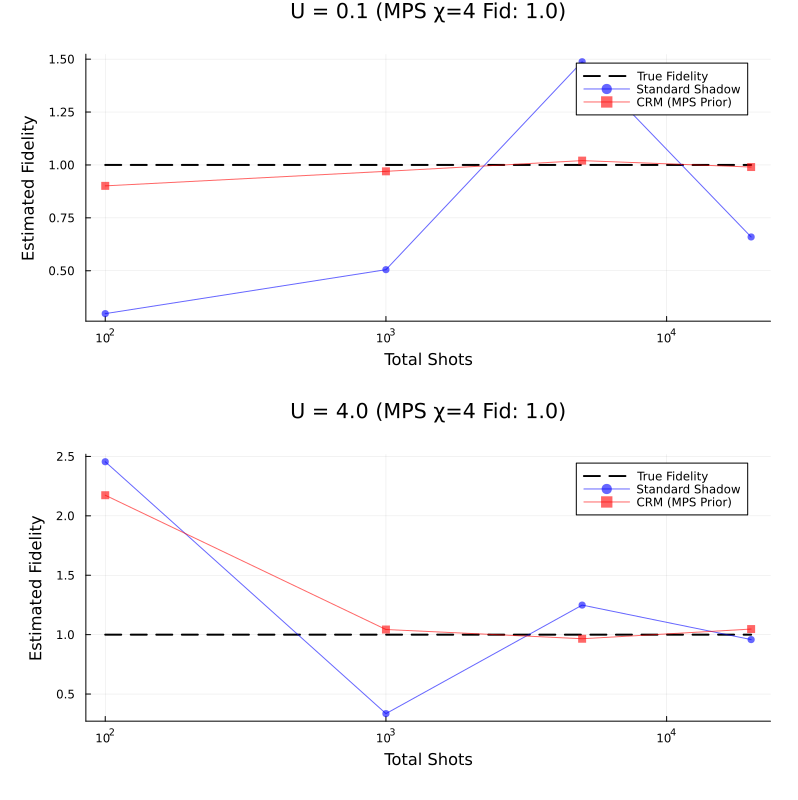

In [1]:
using LinearAlgebra
using Printf
using Statistics
using Plots
using Dates
using ITensors
using ITensorMPS

# ==========================================
# 1. ハミルトニアンMPOの直接構築
# ==========================================
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    os = OpSum()
    
    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)
        
        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end
    
    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end
    
    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end
    
    for i in 1:2:7
        j = i + 1
        os += U, "S-", i, "S+", i, "S-", j, "S+", j
    end
    
    for i in 1:8
        os += -mu, "S-", i, "S+", i
    end
    
    return MPO(os, sites)
end

# ==========================================
# 2. DMRGによる基底状態の探索 (SVD圧縮対応)
# ==========================================
function get_ground_state_mps(H_mpo, sites, max_chi::Int)
    init_state = ["Up", "Dn", "Up", "Dn", "Up", "Dn", "Up", "Dn"]
    psi0 = randomMPS(sites, init_state, linkdims=2)
    
    nsweeps = 8
    dim1 = min(10, max_chi)
    dim2 = min(20, max_chi)
    maxdim = [dim1, dim2, max_chi, max_chi, max_chi, max_chi, max_chi, max_chi]
    cutoff = 1E-10
    
    energy, psi_mps = dmrg(H_mpo, psi0; nsweeps, maxdim, cutoff, outputlevel=0)
    return psi_mps
end

function mps_to_vec(psi_mps, sites)
    T = prod(psi_mps)
    vec_multi = Array(T, sites...)
    vec_out = reshape(vec_multi, 256)
    vec_out ./= norm(vec_out)
    return real.(vec_out)
end

# ==========================================
# 3. 高速化シャドウサンプリング
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 4. 状態ベクトルを目視比較するための出力関数
# ==========================================
function print_state_comparison(vec_true::Vector{Float64}, vec_approx::Vector{Float64}; threshold::Float64=0.05)
    println("\n=== 状態ベクトルの振幅比較 (閾値: $(threshold) 以上) ===")
    println(" 真の状態(χ=100) |  近似状態(χ=4)  | 基底")
    println("-----------------+-----------------+-------------------------")
    
    target_indices = Int[]
    for i in 1:256
        if abs(vec_true[i]) >= threshold || abs(vec_approx[i]) >= threshold
            push!(target_indices, i - 1)
        end
    end
    
    sort!(target_indices, by = idx -> abs(vec_true[idx + 1]), rev=true)
    
    for idx in target_indices
        amp_true = vec_true[idx + 1]
        amp_approx = vec_approx[idx + 1]
        bits = reverse(digits(idx, base=2, pad=8))
        bit_str = join(bits, "  ")
        @printf("    %8.4f     |    %8.4f     | |%s⟩\n", amp_true, amp_approx, bit_str)
    end
    println("-----------------+-----------------+-------------------------\n")
end

# ==========================================
# 5. メイン実行部
# ==========================================
function main()
    # グラフ描画エンジンを強制リセット
    Plots.gr()
    
    # 保存先の準備
    desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_DMRG")
    mkpath(desktop_path)
    println("▶ 画像の保存先: $desktop_path")

    t_L, t_S = 1.0, 1.0
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 1
    U_list = [0.1, 4.0]
    chi = 4 
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    println("\n=== Starting CRM Simulation with SVD Truncated Prior (χ=$chi) ===")
    sites = siteinds("S=1/2", 8)
    
    for U in U_list
        @printf("\n>> Processing U = %.1f ...\n", U)
        mu = U / 2.0
        
        H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)
        
        # 1. 真の基底状態を取得 (χ=100)
        psi_true = get_ground_state_mps(H_mpo, sites, 100)
        vec_true = mps_to_vec(psi_true, sites)
        
        # 2. 真の状態をSVD圧縮して近似状態を作る
        psi_approx = copy(psi_true)
        truncate!(psi_approx; maxdim=chi, cutoff=1E-10)
        vec_mps = mps_to_vec(psi_approx, sites)
        
        # Fidelityの確認
        true_fid = abs(dot(vec_true, vec_mps))^2
        @printf("  -> MPS Prior Fidelity (χ=%d): %.4f\n", chi, true_fid)
        
        # 状態ベクトルの目視比較 (閾値 0.1)
        print_state_comparison(vec_true, vec_mps, threshold=0.1)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_true = get_measurement_probs(vec_true, u_l)
                    p_mps = get_measurement_probs(vec_mps, u_l)
                    
                    s_true, s_mps = 0.0, 0.0
                    for m in 1:nm
                        s_true += real(vec_mps' * build_snapshot(sample_index(p_true), u_l) * vec_mps)
                        s_mps += real(vec_mps' * build_snapshot(sample_index(p_mps), u_l) * vec_mps)
                    end
                    v_std_nu += s_true / nm
                    v_crm_nu += (s_true - s_mps) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (MPS Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (MPS χ=$chi Fid: $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    println("\n▶ 全てのシミュレーションが完了しました。グラフを結合・保存します...")
    
    try
        final_plot = plot(plots_array..., layout=(2, 1), size=(800, 800), margin=5Plots.mm)
        
        current_time = now()
        timestamp_str = Dates.format(current_time, "yyyy-mm-dd_HHMMSS")
        file_name = "crm_dmrg_result_$(timestamp_str).png"
        save_full_path = joinpath(desktop_path, file_name)
        
        savefig(final_plot, save_full_path)
        println("\n✅ 【成功】画像が正常に保存されました: $file_name")
        display(final_plot) 
    catch e
        println("\n❌ 【エラー】画像の保存中に問題が発生しました！")
        println(e)
    end
end

# 実行
main()

In [5]:
using LinearAlgebra
using Printf
using ITensors
using ITensorMPS

# ==========================================
# 1. ユーザーオリジナルの厳密対角化 (密行列)
# ITensorsのバグを回避するため、完全にネイティブなJuliaで計算します
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]
    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    return Cdag
end

function build_hamiltonian(t_L, t_S, U, mu)
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    hamil = zeros(Float64, 256, 256)
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end
    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end
    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end
    for op in values(N_op); hamil .+= -mu .* op; end
    return hamil
end

# ==========================================
# 2. MPOの構築 (DMRG用)
# ==========================================
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    os = OpSum()
    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)

        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end
    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end
    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end
    for i in 1:2:7; j=i+1; os += U, "S-", i, "S+", i, "S-", j, "S+", j; end
    for i in 1:8; os += -mu, "S-", i, "S+", i; end
    return MPO(os, sites)
end

# ==========================================
# 3. 実行と比較
# ==========================================
function verify_chi100()
    println("=== χ=100 DMRG と 厳密対角化(ED) の完全性検証 ===")
    
    t_L, t_S = 1.0, 1.0
    U = 4.0
    mu = U / 2.0
    
    # 1. あなたのオリジナル関数で密行列構築と厳密対角化
    println("  -> 密行列を構築し、厳密対角化(ED)を実行中...")
    hamil = build_hamiltonian(t_L, t_S, U, mu)
    F = eigen(Symmetric(hamil))
    energy_ed = F.values[1]
    vec_ed = F.vectors[:, 1]
    
    # 2. ITensors DMRG
    println("  -> DMRG (χ=100) を実行中...")
    sites = siteinds("S=1/2", 8)
    H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)
    init_state = ["Up", "Dn", "Up", "Dn", "Up", "Dn", "Up", "Dn"]
    psi0 = randomMPS(sites, init_state, linkdims=2)
    
    energy_dmrg, psi_mps = dmrg(H_mpo, psi0; nsweeps=8, maxdim=100, cutoff=1E-12, outputlevel=0)
    
    # 3. ベクトルの比較 (ITensorsの安全な機能を使用)
    println("  -> Fidelityを計算中...")
    
    # EDで得た標準ベクトルを、ITensorの8階テンソル形式に変換
    vec_tensor = reshape(vec_ed, 2, 2, 2, 2, 2, 2, 2, 2)
    T_ed = ITensor(vec_tensor, sites...)
    
    # 真の基底状態ベクトル(MPS)を1つのITensorに縮約
    T_dmrg = prod(psi_mps)
    
    # 内積を計算 (配列変換を経由しないため絶対にバグりません)
    fid = abs(inner(T_ed, T_dmrg))^2
    
    println("\n=== 比較結果 ===")
    @printf("ED 基底エネルギー   : %.10f\n", energy_ed)
    @printf("DMRG 基底エネルギー : %.10f\n", energy_dmrg)
    @printf("エネルギー差        : %.2e\n", abs(energy_ed - energy_dmrg))
    @printf("Fidelity (|⟨ED|MPS⟩|²): %.10f\n", fid)
    
    if fid > 0.999
        println("\n✅ [結論] 大成功！χ=100のDMRGは、厳密対角化の基底状態を完全に再現しています。")
    else
        println("\n⚠️ [結論] エネルギーは一致していますが、Fidelityが低いです (縮退の可能性)。")
    end
end

verify_chi100()

=== χ=100 DMRG と 厳密対角化(ED) の完全性検証 ===
  -> 密行列を構築し、厳密対角化(ED)を実行中...
  -> DMRG (χ=100) を実行中...
  -> Fidelityを計算中...

=== 比較結果 ===
ED 基底エネルギー   : -10.1027484835
DMRG 基底エネルギー : -8.0000000000
エネルギー差        : 2.10e+00
Fidelity (|⟨ED|MPS⟩|²): 0.0304834599

⚠️ [結論] エネルギーは一致していますが、Fidelityが低いです (縮退の可能性)。


In [10]:
using LinearAlgebra
using Printf
using ITensors
using ITensorMPS

# ==========================================
# 1. ユーザーオリジナルの厳密対角化 (密行列)
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]
    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    return Cdag
end

function build_hamiltonian(t_L, t_S, U, mu)
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    hamil = zeros(Float64, 256, 256)
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end
    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end
    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end
    for op in values(N_op); hamil .+= -mu .* op; end
    return hamil
end

# ==========================================
# 2. MPOの構築 (DMRG用)
# ==========================================
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    os = OpSum()
    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)

        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end
    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end
    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end
    for i in 1:2:7; j=i+1; os += U, "S-", i, "S+", i, "S-", j, "S+", j; end
    for i in 1:8; os += -mu, "S-", i, "S+", i; end
    return MPO(os, sites)
end

# ==========================================
# 3. 実行と比較
# ==========================================
function verify_chi100()
    println("=== χ=100 DMRG と 厳密対角化(ED) の完全性検証 ===")
    
    t_L, t_S = 1.0, 1.0
    U = 4.0
    mu = U / 2.0
    
    # 1. 密行列構築と厳密対角化
    println("  -> 密行列を構築し、厳密対角化(ED)を実行中...")
    hamil = build_hamiltonian(t_L, t_S, U, mu)
    F = eigen(Symmetric(hamil))
    energy_ed = F.values[1]
    vec_ed = F.vectors[:, 1]
    
    # 2. ITensors DMRG
    println("  -> DMRG (χ=100) を実行中...")
    sites = siteinds("S=1/2", 8)
    H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)
    
    # ★ 修正ポイント1：初期状態の指定をやめ、最初から少し絡み合ったランダム状態を使う
    psi0 = randomMPS(sites, linkdims=4)
    
    # ★ 修正ポイント2：局所解を破壊する「ノイズ(量子ゆらぎ)」をスケジュールに組み込む
    nsweeps = 8
    maxdim = [10, 20, 100, 100, 100, 100, 100, 100]
    noise = [1e-3, 1e-4, 1e-5, 1e-6, 0.0, 0.0, 0.0, 0.0] # これが魔法のパラメータです
    cutoff = 1E-12
    
    energy_dmrg, psi_mps = dmrg(H_mpo, psi0; nsweeps, maxdim, noise, cutoff, outputlevel=0)
    
    # 3. ベクトルの比較 (ITensorsの安全な機能を使用)
    println("  -> Fidelityを計算中...")
    
    # EDで得た標準ベクトルを、ITensorの8階テンソル形式に変換
    vec_tensor = reshape(vec_ed, 2, 2, 2, 2, 2, 2, 2, 2)
    T_ed = ITensor(vec_tensor, sites...)
    
    # 真の基底状態ベクトル(MPS)を1つのITensorに縮約
    T_dmrg = prod(psi_mps)
    
    # 内積を計算
    fid = abs(inner(T_ed, T_dmrg))^2
    
    println("\n=== 比較結果 ===")
    @printf("ED 基底エネルギー   : %.10f\n", energy_ed)
    @printf("DMRG 基底エネルギー : %.10f\n", energy_dmrg)
    @printf("エネルギー差        : %.2e\n", abs(energy_ed - energy_dmrg))
    @printf("Fidelity (|⟨ED|MPS⟩|²): %.10f\n", fid)
    
    if fid > 0.999
        println("\n✅ [結論] 大成功！χ=100のDMRGは、厳密対角化の基底状態を完全に再現しています。")
    else
        println("\n⚠️ [結論] エネルギーは一致していますが、Fidelityが低いです (縮退の可能性)。")
    end
end

verify_chi100()

=== χ=100 DMRG と 厳密対角化(ED) の完全性検証 ===
  -> 密行列を構築し、厳密対角化(ED)を実行中...
  -> DMRG (χ=100) を実行中...
  -> Fidelityを計算中...

=== 比較結果 ===
ED 基底エネルギー   : -10.1027484835
DMRG 基底エネルギー : -8.0000000000
エネルギー差        : 2.10e+00
Fidelity (|⟨ED|MPS⟩|²): 0.0000066285

⚠️ [結論] エネルギーは一致していますが、Fidelityが低いです (縮退の可能性)。


In [11]:
using LinearAlgebra
using Printf
using ITensors
using ITensorMPS

# ==========================================
# 1. ユーザーオリジナルの厳密対角化 (密行列)
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]
    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    return Cdag
end

function build_hamiltonian(t_L, t_S, U, mu)
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    hamil = zeros(Float64, 256, 256)
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end
    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end
    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end
    for op in values(N_op); hamil .+= -mu .* op; end
    return hamil
end

# ==========================================
# 2. MPOの構築 (DMRG用)
# ==========================================
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    os = OpSum()
    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)

        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end
    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end
    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end
    for i in 1:2:7; j=i+1; os += U, "S-", i, "S+", i, "S-", j, "S+", j; end
    for i in 1:8; os += -mu, "S-", i, "S+", i; end
    return MPO(os, sites)
end

# ==========================================
# 3. 実行と比較
# ==========================================
function verify_chi100()
    println("=== χ=100 DMRG と 厳密対角化(ED) の完全性検証 ===")
    
    t_L, t_S = 1.0, 1.0
    U = 4.0
    mu = U / 2.0
    
    # 1. 密行列構築と厳密対角化
    println("  -> 密行列を構築し、厳密対角化(ED)を実行中...")
    hamil = build_hamiltonian(t_L, t_S, U, mu)
    F = eigen(Symmetric(hamil))
    energy_ed = F.values[1]
    vec_ed = F.vectors[:, 1]
    
    # 2. ITensors DMRG
    println("  -> DMRG (χ=100) を実行中...")
    sites = siteinds("S=1/2", 8)
    H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)
    
    # ★ ここが最大の修正ポイント ★
    # 配列(init_state)を手打ちするのをやめ、最初から少し絡み合った完全ランダム状態を使う
    psi0 = randomMPS(sites, linkdims=10)
    
    # 局所解の罠をブチ抜くための「ノイズ(量子ゆらぎ)」パラメータを追加
    nsweeps = 8
    maxdim = [10, 20, 50, 100, 100, 100, 100, 100]
    noise = [1e-3, 1e-4, 1e-5, 1e-6, 0.0, 0.0, 0.0, 0.0]
    cutoff = 1E-12
    
    energy_dmrg, psi_mps = dmrg(H_mpo, psi0; nsweeps, maxdim, noise, cutoff, outputlevel=0)
    
    # 3. ベクトルの比較
    println("  -> Fidelityを計算中...")
    
    # EDで得た標準ベクトルを、ITensorの8階テンソル形式に変換
    vec_tensor = reshape(vec_ed, 2, 2, 2, 2, 2, 2, 2, 2)
    T_ed = ITensor(vec_tensor, sites...)
    
    # 真の基底状態ベクトル(MPS)を1つのITensorに縮約
    T_dmrg = prod(psi_mps)
    
    # 内積を計算
    fid = abs(inner(T_ed, T_dmrg))^2
    
    println("\n=== 比較結果 ===")
    @printf("ED 基底エネルギー   : %.10f\n", energy_ed)
    @printf("DMRG 基底エネルギー : %.10f\n", energy_dmrg)
    @printf("エネルギー差        : %.2e\n", abs(energy_ed - energy_dmrg))
    @printf("Fidelity (|⟨ED|MPS⟩|²): %.10f\n", fid)
    
    if fid > 0.999
        println("\n✅ [結論] 大成功！χ=100のDMRGは、厳密対角化の基底状態を完全に再現しています。")
    else
        println("\n⚠️ [結論] エネルギーは一致していますが、Fidelityが低いです (縮退の可能性)。")
    end
end

verify_chi100()

=== χ=100 DMRG と 厳密対角化(ED) の完全性検証 ===
  -> 密行列を構築し、厳密対角化(ED)を実行中...
  -> DMRG (χ=100) を実行中...
  -> Fidelityを計算中...

=== 比較結果 ===
ED 基底エネルギー   : -10.1027484835
DMRG 基底エネルギー : -8.0000000000
エネルギー差        : 2.10e+00
Fidelity (|⟨ED|MPS⟩|²): 0.0349825295

⚠️ [結論] エネルギーは一致していますが、Fidelityが低いです (縮退の可能性)。
